<a href="https://colab.research.google.com/github/luiscals1/Imersao_Dados_Alura/blob/main/COVID_VDC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **SOBRE ESTE PROJETO**


       As análises contidas neste notebook fazem parte do projeto de TCC de Engenharia da Computação da Faculdade Independente do Nordeste - FAINOR/BA.

       O dataset apresenta dados reais, disponíveis no site do Portal da Transparência da Bahia:
       
       <https://bi.saude.ba.gov.br/transparencia/#>,
       ######https://prodeboffice365-my.sharepoint.com/personal/cievs_notifica_saude_ba_gov_br/_layouts/15/onedrive.aspx?id=%2Fpersonal%2Fcievs%5Fnotifica%5Fsaude%5Fba%5Fgov%5Fbr%2FDocuments%2Fbase%20de%20dados%20do%20estado&originalPath=aHR0cHM6Ly9wcm9kZWJvZmZpY2UzNjUtbXkuc2hhcmVwb2ludC5jb20vOmY6L2cvcGVyc29uYWwvY2lldnNfbm90aWZpY2Ffc2F1ZGVfYmFfZ292X2JyL0VscTdQZ0FyNjNwS3AxM2RNRUs0VmJJQkVFNjJVMS1VY04zcEJHVUpMTmxhelE_cnRpbWU9YUZVT01LdVUyRWc
       contendo informações dos casos de pacientes em ámbito estadual. O foco da análise (escolha pessoal) será a análise exploratória de casos de Covid-19 na cidade de Vitória da Conquista - Bahia.

## **Importando as bibliotecas**

In [173]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot    as plt
import numpy as np

from sklearn.preprocessing import LabelEncoder

##**Importando o dataset**

In [174]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [175]:
# inpFile = pd.read_csv(fPath, sep='\t', error_bad_lines= False,quoting=csv.QUOTE_NONE)

In [176]:
#dados1 = pd.read_csv('/content/drive/My Drive/data_set/covid_bahia.csv', sep= ';' ,engine='python', error_bad_lines=False)
#x = mydataset.iloc[:,:].values

#dados2 = pd.read_csv('/content/drive/My Drive/data_set/covid_obitos.csv', sep= ';' ,engine='python', error_bad_lines=False)

In [177]:
dados1 = pd.read_csv('/content/drive/My Drive/data_set/bahia_covid_2020.csv', sep= ';',engine='python', error_bad_lines=False)
dados2 = pd.read_csv('/content/drive/My Drive/data_set/bahia_covid_obitos_2020.csv', sep= ';' ,engine='python', error_bad_lines=False)

##**Explorando o dataset**

In [178]:
#Obtendo uma amostra aleatória dos dados de covid para conhecer as variáveis
dados1.sample(2)

,DATA DA NOTIFICACAO,DOR DE GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,E PROFISSIONAL DE SAUDE?,DATA DO INICIO DOS SINTOMAS,DOENCAS RESPIRATORIAS CRONICAS DESCOMPENSADAS,DOENCAS CARDIACAS CRONICAS,DIABETES,"DOENCAS RENAIS CRONICAS EM ESTAGIO AVANCADO (GRAUS 3, 4 OU 5)",IMUNOSSUPRESSAO,GESTANTE DE ALTO RISCO,PORTADOR DE DOENCAS CROMOSSOMICAS OU ESTADO DE FRAGILIDADE IMUNO,CLASSIFICACAO FINAL,INVESTIGACAO CONCLUIDA,ESTADO DO TESTE,CBO,DATA DA COLETA DO TESTE,IDADE EM ANOS,TIPO IDADE,TIPO DE TESTE,RESULTADO DO TESTE,SEXO,ESTADO DE RESIDENCIA,MUNICIPIO DE RESIDENCIA,BANCO,RACA/COR,EPIDEMIA
103162,29/05/2020,NAO,NAO,NAO,NAO,SIM,SIM,25/04/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,COLETADO,2235 - ENFERMEIRO,25/04/2020,32.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,TAPEROA,ESUS,PRETA,COVID-19
478985,22/12/2020,NAO,NAO,SIM,SIM,SIM,NAO,17/12/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,COLETADO,NaN,22/12/2020,69.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,NOVA CANAA,ESUS,IGNORADO,COVID-19


In [179]:
#Fazendo a mesma coisa para o dataset de óbitos
dados2.sample(3)

,DATA OBITO,DATA NOTIFICACAO OBITO,UF ESTADO,MUNICIPIO,SEXO,IDADE,TIPO ORGAO,COMORBIDADE,LISTA COMORBIDADE,IDADE MESES,IDADE DIAS,MUNICIPIO OCORRENCIA
2292,15/09/2020,06/10/2020,BA,ILH�US,M,66,FILANTROPICO,S,NEOPLASIA,0,0,ILH�US
6150,22/07/2020,24/07/2020,BA,SALVADOR,F,72,PRIVADO,S,"OBESIDADE,HIPERTENS�O (HAS),DOEN�A CARDIOVASCU...",0,0,SALVADOR
1886,18/10/2020,20/10/2020,BA,MACARANI,F,65,PUBLICO,S,"HIPERTENS�O (HAS),DIABETES MELLITUS (DM)",0,0,VIT�RIA DA CONQUISTA


In [180]:
#Pegando uma amostra aleatória dos dados de covid para conhecer as variáveis
#dados4.sample(10)

In [181]:
#dados.tail()

In [182]:
#Vendo o tamanho do dataset1 ( retorno = (linhas, colunas))
dados1.shape

(496823, 30)

In [183]:
dados1['SEXO'].value_counts()

FEMININO      271293
MASCULINO     224558
INDEFINIDO       635
IGNORADO           6
Masculino          3
Feminino           1
IGNORADA           1
Name: SEXO, dtype: int64

In [184]:
#Vendo o tamanho do dataset2( retorno = (linhas, colunas))
dados2.shape

(9246, 12)

## **TRATAMENTO DOS DADOS**

##**Alterando o nome das colunas do dataset 1**


In [185]:
#dados1.columns = [c.replace('DATA DA NOTIFICACAO', 'DT_NOTIFIC') for c in dados1.columns]

In [186]:
dados1.rename(
    columns = {'DATA DA NOTIFICACAO':'DT_NOTIFIC','DOR DE GARGANTA':'DOR_GARGANTA','E PROFISSIONAL DE SAUDE?':'PROFI_DE_SAUDE','DATA DO INICIO DOS SINTOMAS':'DT_INICIO_SINTOMAS',
               'DOENCAS RESPIRATORIAS CRONICAS DESCOMPENSADAS':'DOENCAS_RESP_CRON_DESCOMP','DOENCAS CARDIACAS CRONICAS':'DOENCAS_CARD_CRON','DIABETES':'DIABETES','DOENCAS RENAIS CRONICAS EM ESTAGIO AVANCADO (GRAUS 3, 4 OU 5)':'DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5','GESTANTE DE ALTO RISCO':'GESTA_ALTO_RISC',
               'PORTADOR DE DOENCAS CROMOSSOMICAS OU ESTADO DE FRAGILIDADE IMUNO':'DOENCAS_CROMOS_OU_FRAGI_IMUNO','CLASSIFICACAO FINAL':'CLAS_FINAL','INVESTIGACAO CONCLUIDA':'INVESTI_CONC','ESTADO DO TESTE':'ESTADO_TEST',
               'DATA DA COLETA DO TESTE':'DT_COLT_TEST','IDADE EM ANOS':'IDADE','TIPO IDADE':'TP_IDADE','TIPO DE TESTE':'TP_TEST','RESULTADO DO TESTE':'RESULT_TEST','ESTADO DE RESIDENCIA':'ESTD_RESI','MUNICIPIO DE RESIDENCIA':'MUN_RESI','RACA/COR':'RACA_COR'},
              inplace=True
              )

In [187]:
dados1.columns

Index(['DT_NOTIFIC', 'DOR_GARGANTA', 'DISPNEIA', 'FEBRE', 'TOSSE', 'OUTROS',
       'PROFI_DE_SAUDE', 'DT_INICIO_SINTOMAS', 'DOENCAS_RESP_CRON_DESCOMP',
       'DOENCAS_CARD_CRON', 'DIABETES', 'DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5',
       'IMUNOSSUPRESSAO', 'GESTA_ALTO_RISC', 'DOENCAS_CROMOS_OU_FRAGI_IMUNO',
       'CLAS_FINAL', 'INVESTI_CONC', 'ESTADO_TEST', 'CBO', 'DT_COLT_TEST',
       'IDADE', 'TP_IDADE', 'TP_TEST', 'RESULT_TEST', 'SEXO', 'ESTD_RESI',
       'MUN_RESI', 'BANCO', 'RACA_COR', 'EPIDEMIA'],
      dtype='object')

In [188]:
dados1.head(5)

,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,DT_COLT_TEST,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA
0,23/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,23/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,23/06/2020,22.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,PINDOBACU,ESUS,AMARELA,COVID-19
1,10/06/2020,NAO,NAO,NAO,NAO,SIM,SIM,10/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,4221 - RECEPCIONISTA,10/06/2020,31.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,JUSSARI,ESUS,PRETA,COVID-19
2,18/05/2020,SIM,NAO,SIM,NAO,NAO,NAO,17/05/2020,NAO,NAO,NAO,NAO,NAO,SIM,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,18/05/2020,31.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,SALVADOR,ESUS,PRETA,COVID-19
3,29/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,16/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,29/06/2020,40.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VARZEA NOVA,ESUS,BRANCA,COVID-19
4,03/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,03/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,15/05/2020,61.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,SALVADOR,ESUS,PRETA,COVID-19


In [189]:

#usando o info para saber os tipos de variáveis presentes
dados1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496823 entries, 0 to 496822
Data columns (total 30 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   DT_NOTIFIC                            495612 non-null  object 
 1   DOR_GARGANTA                          480578 non-null  object 
 2   DISPNEIA                              480575 non-null  object 
 3   FEBRE                                 480580 non-null  object 
 4   TOSSE                                 480581 non-null  object 
 5   OUTROS                                480570 non-null  object 
 6   PROFI_DE_SAUDE                        475121 non-null  object 
 7   DT_INICIO_SINTOMAS                    490782 non-null  object 
 8   DOENCAS_RESP_CRON_DESCOMP             480454 non-null  object 
 9   DOENCAS_CARD_CRON                     480577 non-null  object 
 10  DIABETES                              480576 non-null  object 
 11  

##**Alterando o nome das colunas do dataset 2**






In [190]:
#dados2.columns = [c.replace('DATA OBITO', 'DT_OBITO') for c in dados2.columns]

In [191]:
dados2.rename( columns = {'DATA OBITO':'DT_OBITO','DATA NOTIFICACAO OBITO':'DT_NOTIF_OBITO','UF ESTADO':'UF_ESTD','SEXO':'GENERO','TIPO ORGAO':'TP_ORGAO','LISTA COMORBIDADE':'LIST_COMORB',
                          'IDADE MESES':'IDADE_MESES','IDADE DIAS':'IDADE_DIAS','MUNICIPIO OCORRENCIA':'MUN_OCORRC'},
              inplace=True)

In [192]:
dados2.head()

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC
0,03/01/2021,04/01/2021,BA,ITAMARAJU,M,71,PUBLICO,SI,NaN,0,0,ITAMARAJU
1,27/11/2020,04/01/2021,BA,SALVADOR,M,82,PUBLICO,S,"HIPERTENS�O (HAS),DOEN�A CARDIOVASCULAR (DCV)",0,0,SALVADOR
2,31/12/2020,04/01/2021,BA,CORIBE,F,68,PUBLICO,S,HIPERTENS�O (HAS),0,0,BARREIRAS
3,29/12/2020,04/01/2021,BA,CAPIM GROSSO,F,44,PUBLICO,S,"HIPERTENS�O (HAS),DIABETES MELLITUS (DM)",0,0,SALVADOR
4,29/12/2020,04/01/2021,BA,ITABUNA,M,80,PUBLICO,S,DOEN�A CARDIOVASCULAR (DCV),0,0,ITABUNA


###**Removendo o espaço do nome de VITORIA DA CONQUISTA dataset 1**







In [193]:
dados1.loc[dados1['MUN_RESI'] == 'VITORIA DA CONQUISTA', 'MUN_RESI'] = 'VITORIA_DA_CONQUISTA'

###**Alterando o nome de VIT�RIA DA CONQUISTA do dataset 2**







In [194]:
dados2.loc[dados2['MUNICIPIO'] == 'VIT�RIA DA CONQUISTA', 'MUNICIPIO'] = 'VITORIA_DA_CONQUISTA'

In [195]:
dados2.loc[dados2['MUN_OCORRC'] == 'VIT�RIA DA CONQUISTA', 'MUN_OCORRC'] = 'VITORIA_DA_CONQUISTA'

In [196]:
# Criando df para dados somente de Vitória da Conquista
df_vdc = dados1[(dados1['MUN_RESI'] == 'VITORIA_DA_CONQUISTA')] 

df_vdc.head(2)

,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,DT_COLT_TEST,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA
123,26/06/2020,NAO,NAO,NAO,SIM,SIM,NAO,25/06/2020,NAO,NAO,SIM,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,29/06/2020,66.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,BRANCA,COVID-19
129,30/06/2020,NAO,NAO,SIM,SIM,SIM,NAO,29/06/2020,NAO,SIM,SIM,SIM,NAO,NAO,NAO,CONFIRMADO CLINICO-IMAGEM,CONFIRMADO,EXAME NAO SOLICITADO,NaN,02/07/2020,35.0,ANO(S),RT-PCR EM TEMPO REAL,NEGATIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,PARDA,COVID-19


##**Obtendo informações dos casos de VITORIA DA CONQUISTA**







In [343]:
#Criando df para óbitos por covid em  Vitória da Conquista
df_obitos = dados2[(dados2['MUNICIPIO'] == 'VITORIA_DA_CONQUISTA')  & (dados2['MUN_OCORRC'] == 'VITORIA_DA_CONQUISTA')] 
df_obitos.head(5)

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC
18,19/12/2020,04/01/2021,BA,VITORIA_DA_CONQUISTA,M,68,FILANTROPICO,S,"HIPERTENS�O (HAS),DOEN�A CARDIOVASCULAR (DCV)",0,0,VITORIA_DA_CONQUISTA
40,01/01/2021,03/01/2021,BA,VITORIA_DA_CONQUISTA,F,92,FILANTROPICO,S,DOEN�A CARDIOVASCULAR (DCV),0,0,VITORIA_DA_CONQUISTA
152,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,M,44,PUBLICO,S,HIPERTENS�O (HAS),0,0,VITORIA_DA_CONQUISTA
155,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,F,80,FILANTROPICO,SI,NaN,0,0,VITORIA_DA_CONQUISTA
241,26/12/2020,27/12/2020,BA,VITORIA_DA_CONQUISTA,M,62,PRIVADO,SI,NaN,0,0,VITORIA_DA_CONQUISTA


In [198]:
df_new = dados2[(dados2['MUNICIPIO'] == 'VITORIA_DA_CONQUISTA')  & (dados2['MUN_OCORRC'] == 'VITORIA_DA_CONQUISTA')] 

In [345]:
df_new.head(5)


,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC
18,19/12/2020,04/01/2021,BA,VITORIA_DA_CONQUISTA,M,68,FILANTROPICO,S,"HIPERTENSAO,DOENCA_CARDIOVASCULAR",0,0,VITORIA_DA_CONQUISTA
40,01/01/2021,03/01/2021,BA,VITORIA_DA_CONQUISTA,F,92,FILANTROPICO,S,DOENCA_CARDIOVASCULAR,0,0,VITORIA_DA_CONQUISTA
152,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,M,44,PUBLICO,S,HIPERTENSAO,0,0,VITORIA_DA_CONQUISTA
155,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,F,80,FILANTROPICO,SI,NaN,0,0,VITORIA_DA_CONQUISTA
241,26/12/2020,27/12/2020,BA,VITORIA_DA_CONQUISTA,M,62,PRIVADO,SI,NaN,0,0,VITORIA_DA_CONQUISTA


In [200]:
# Hipertensão 
df_has = df_new.loc[df_new['LIST_COMORB'] == 'HIPERTENS�O (HAS)','LIST_COMORB'] = 'HIPERTENSAO'
print(df_has)
df_dsn =  df_new.loc[df_new['LIST_COMORB'] == 'DOEN�A DO SISTEMA NERVOSO','LIST_COMORB'] = 'DOENÇA_DO_SIST_NERV'
print(df_dsn)
# Hipertensão  e Doença Cardiovascular
df_has_dcv = df_new.loc[df_new['LIST_COMORB'] == 'HIPERTENS�O (HAS),DOEN�A CARDIOVASCULAR (DCV)','LIST_COMORB'] = 'HIPERTENSAO,DOENCA_CARDIOVASCULAR' 
print(df_has_dcv)
# Hipertensão e Diabetes Mellitus
df_has_dm = df_new.loc[df_new['LIST_COMORB'] == 'HIPERTENS�O (HAS),DIABETES MELLITUS (DM)','LIST_COMORB'] = 'HIPERTENSAO,DIABETES_MELLITUS' 
print(df_has_dm)
# Doença Cardiovascular e Diabetes
df_dcv_dm = df_new.loc[df_new['LIST_COMORB'] == 'DOEN�A CARDIOVASCULAR (DCV),DIABETES MELLITUS (DM)','LIST_COMORB'] = 'DOENCA_CARDIOVASCULAR,DIABETES_MELLITUS' 
print(df_dcv_dm)
# Diabetes Mellitus
df_dm = df_new.loc[df_new['LIST_COMORB'] == 'DIABETES MELLITUS (DM)','LIST_COMORB'] = 'DIABETES_MELLITUS' 
print(df_dm)  
# Doença Cardiovascular
df_dcv = df_new.loc[df_new['LIST_COMORB'] ==  'DOEN�A CARDIOVASCULAR (DCV)','LIST_COMORB'] = 'DOENCA_CARDIOVASCULAR' 
print(df_dcv)  
# Doença Renal Crônica
df_drenalc = df_new.loc[df_new['LIST_COMORB'] ==  'DOEN�A RENAL CR�NICA (DRC)','LIST_COMORB'] = 'DOENCA_RENAL_CRONICA' 
print(df_drenalc)  
# Doença Respiratória Crônica
df_drespc = df_new.loc[df_new['LIST_COMORB'] ==  'DOEN�A RESPIRATORIA CRONICA','LIST_COMORB'] = 'DOENCA_RESPIRATORIA_CRONICA'
print(df_drespc)
# Diabetes Mellitus e Doença Respitatória Crônica
df_dm_drc = df_new.loc[df_new['LIST_COMORB'] ==  'DIABETES MELLITUS (DM),DOEN�A RESPIRATORIA CRONICA','LIST_COMORB'] = 'DIABETES_MELLITUS,DOENCA_RESPIRATORIA_CRONICA'
print(df_dm_drc)
# Hipertensão, Diabetes Mellitus, Glaucoma
df_has_dm_glau = df_new.loc[df_new['LIST_COMORB'] ==  'HIPERTENS�O (HAS),DIABETES MELLITUS (DM),GLAUCOMA','LIST_COMORB'] = 'HIPERTENSAO,DIABETES_MELLITUS,GLAUCOMA'
print(df_has_dm_glau)
# Hipertensão, Doença Cardiovascular, Diabetes Mellitus 
df_has_drc_dm = df_new.loc[df_new['LIST_COMORB'] ==  'HIPERTENS�O (HAS),DOEN�A CARDIOVASCULAR (DCV),DIABETES MELLITUS (DM)'] = 'HIPERTENSAO,DOENCA_CARDIOVASCULAR,DIABETES_MELLITUS'
print(df_has_drc_dm) 
# Obesidade, Hipertensão
df_obs_has= df_new.loc[df_new['LIST_COMORB'] ==  'OBESIDADE,HIPERTENS�O (HAS)'] = 'OBESIDADE,HIPERTENSAO'
print(df_obs_has) 





HIPERTENSAO
DOENÇA_DO_SIST_NERV
HIPERTENSAO,DOENCA_CARDIOVASCULAR
HIPERTENSAO,DIABETES_MELLITUS
DOENCA_CARDIOVASCULAR,DIABETES_MELLITUS
DIABETES_MELLITUS
DOENCA_CARDIOVASCULAR
DOENCA_RENAL_CRONICA
DOENCA_RESPIRATORIA_CRONICA
DIABETES_MELLITUS,DOENCA_RESPIRATORIA_CRONICA
HIPERTENSAO,DIABETES_MELLITUS,GLAUCOMA
HIPERTENSAO,DOENCA_CARDIOVASCULAR,DIABETES_MELLITUS
OBESIDADE,HIPERTENSAO


In [201]:
df_new.LIST_COMORB.value_counts()

HIPERTENSAO,DIABETES_MELLITUS                                                                                      32
HIPERTENSAO                                                                                                        25
DIABETES_MELLITUS                                                                                                  15
DOENCA_CARDIOVASCULAR                                                                                              14
HIPERTENSAO,DOENCA_CARDIOVASCULAR                                                                                   8
DOENCA_RESPIRATORIA_CRONICA                                                                                         6
DOENCA_CARDIOVASCULAR,DIABETES_MELLITUS                                                                             5
DOENÇA_DO_SIST_NERV                                                                                                 5
OBESIDADE,HIPERTENSAO                                   

In [202]:
df_new['LIST_COMORB'] == 'HIPERTENSAO'
df_new.head(100)

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC
18,19/12/2020,04/01/2021,BA,VITORIA_DA_CONQUISTA,M,68,FILANTROPICO,S,"HIPERTENSAO,DOENCA_CARDIOVASCULAR",0,0,VITORIA_DA_CONQUISTA
40,01/01/2021,03/01/2021,BA,VITORIA_DA_CONQUISTA,F,92,FILANTROPICO,S,DOENCA_CARDIOVASCULAR,0,0,VITORIA_DA_CONQUISTA
152,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,M,44,PUBLICO,S,HIPERTENSAO,0,0,VITORIA_DA_CONQUISTA
155,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,F,80,FILANTROPICO,SI,NaN,0,0,VITORIA_DA_CONQUISTA
241,26/12/2020,27/12/2020,BA,VITORIA_DA_CONQUISTA,M,62,PRIVADO,SI,NaN,0,0,VITORIA_DA_CONQUISTA
...,...,...,...,...,...,...,...,...,...,...,...,...
2951,20/09/2020,21/09/2020,BA,VITORIA_DA_CONQUISTA,M,86,PUBLICO,SI,NaN,0,0,VITORIA_DA_CONQUISTA
2988,15/07/2020,20/09/2020,BA,VITORIA_DA_CONQUISTA,F,44,FILANTROPICO,S,"HIPERTENSAO,DIABETES_MELLITUS",0,0,VITORIA_DA_CONQUISTA
3004,28/07/2020,20/09/2020,BA,VITORIA_DA_CONQUISTA,M,43,NaN,SI,NaN,0,0,VITORIA_DA_CONQUISTA
3011,19/09/2020,20/09/2020,BA,VITORIA_DA_CONQUISTA,M,69,PUBLICO,S,HIPERTENSAO,0,0,VITORIA_DA_CONQUISTA


In [203]:
df_new.LIST_COMORB.value_counts()

HIPERTENSAO,DIABETES_MELLITUS                                                                                      32
HIPERTENSAO                                                                                                        25
DIABETES_MELLITUS                                                                                                  15
DOENCA_CARDIOVASCULAR                                                                                              14
HIPERTENSAO,DOENCA_CARDIOVASCULAR                                                                                   8
DOENCA_RESPIRATORIA_CRONICA                                                                                         6
DOENCA_CARDIOVASCULAR,DIABETES_MELLITUS                                                                             5
DOENÇA_DO_SIST_NERV                                                                                                 5
OBESIDADE,HIPERTENSAO                                   

In [204]:
df_obitos.dtypes

DT_OBITO          object
DT_NOTIF_OBITO    object
UF_ESTD           object
MUNICIPIO         object
GENERO            object
IDADE              int64
TP_ORGAO          object
COMORBIDADE       object
LIST_COMORB       object
IDADE_MESES        int64
IDADE_DIAS         int64
MUN_OCORRC        object
dtype: object

#**LIMPEZA DOS DADOS**

#**Identificando dados ausentes**

In [205]:
#Verificando a quantidade de dados faltantes
df_faltantes = df_vdc.isnull().sum()
print(df_faltantes)

DT_NOTIFIC                                  8
DOR_GARGANTA                              125
DISPNEIA                                  125
FEBRE                                     125
TOSSE                                     125
OUTROS                                    125
PROFI_DE_SAUDE                            390
DT_INICIO_SINTOMAS                         41
DOENCAS_RESP_CRON_DESCOMP                 125
DOENCAS_CARD_CRON                         125
DIABETES                                  125
DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5      125
IMUNOSSUPRESSAO                           125
GESTA_ALTO_RISC                           381
DOENCAS_CROMOS_OU_FRAGI_IMUNO             381
CLAS_FINAL                                  0
INVESTI_CONC                                0
ESTADO_TEST                                85
CBO                                     13304
DT_COLT_TEST                              138
IDADE                                       7
TP_IDADE                          

In [206]:
shape_antes = df_vdc.shape
print("Antes:\t", shape_antes)

df_vdc.dropna(subset=['DOR_GARGANTA'], inplace=True)

shape_depois = df_vdc.shape
print("\Depois:\t", shape_depois)

Antes:	 (14916, 30)
\Depois:	 (14791, 30)


In [207]:
shape_antes = df_vdc.shape
print("Antes:\t", shape_antes)

df_vdc.dropna(subset=['GESTA_ALTO_RISC'], inplace=True)

shape_depois = df_vdc.shape
print("\Depois:\t", shape_depois)

Antes:	 (14791, 30)
\Depois:	 (14535, 30)


In [350]:
df_vdc.dropna(subset=['IDADE'], inplace=True)
df_vdc.dropna(subset=['RACA_COR'], inplace=True)
df_vdc.dropna(subset=['IMUNOSSUPRESSAO'], inplace=True)
df_vdc.dropna(subset=['FEBRE'], inplace=True)
df_vdc.dropna(subset=['RESULT_TEST'], inplace=True)
df_vdc.dropna(subset=['TP_TEST'], inplace=True)
df_vdc.dropna(subset=['RACA_COR'], inplace=True)
df_vdc.dropna(subset=['PROFI_DE_SAUDE'], inplace=True)

In [349]:
#Deixando a coluna DT_COLT_TEST em primeiro lugar 
df_vdc = df_vdc[ ['DT_COLT_TEST'] + [ col for col in df_vdc.columns if col != 'DT_COLT_TEST' ] ]
df_vdc.head()

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
123,2020-06-29,2020-06-25,0,0,0,0,0,0,25/06/2020,0,0,0,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,66.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,0,COVID-19,3
129,2020-07-02,2020-06-29,0,0,1,0,0,0,29/06/2020,0,1,0,1,0,0,0,CONFIRMADO CLINICO-IMAGEM,CONFIRMADO,EXAME NAO SOLICITADO,NaN,35.0,ANO(S),RT-PCR EM TEMPO REAL,NEGATIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,2
168,2020-06-18,2020-06-17,0,0,0,1,0,0,17/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,3.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
231,NaT,2020-05-06,1,0,1,0,0,0,06/05/2020,1,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,9.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
234,2020-06-22,2020-06-12,1,1,1,0,0,0,12/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,30.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,0,COVID-19,3


In [351]:
#verificando dados ausentes por ordem
df_vdc.isnull().sum().sort_values(ascending=False)

CBO                                     12671
DT_COLT_TEST                               21
ESTADO_TEST                                 2
IMUNOSSUPRESSAO                             0
DT_NOTIFIC                                  0
DOR_GARGANTA                                0
DISPNEIA                                    0
FEBRE                                       0
TOSSE                                       0
OUTROS                                      0
PROFI_DE_SAUDE                              0
DT_INICIO_SINTOMAS                          0
DOENCAS_RESP_CRON_DESCOMP                   0
DOENCAS_CARD_CRON                           0
DIABETES                                    0
DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5        0
RESULT                                      0
GESTA_ALTO_RISC                             0
EPIDEMIA                                    0
CLAS_FINAL                                  0
INVESTI_CONC                                0
IDADE                             

In [218]:
#Verificando a quantidade de dados faltantes
df_faltantes = df_vdc.isnull().sum()
print(df_faltantes)

DT_COLT_TEST                               21
DT_NOTIFIC                                  0
DOR_GARGANTA                                0
DISPNEIA                                    0
FEBRE                                       0
TOSSE                                       0
OUTROS                                      0
PROFI_DE_SAUDE                              0
DT_INICIO_SINTOMAS                          0
DOENCAS_RESP_CRON_DESCOMP                   0
DOENCAS_CARD_CRON                           0
DIABETES                                    0
DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5        0
IMUNOSSUPRESSAO                             0
GESTA_ALTO_RISC                             0
DOENCAS_CROMOS_OU_FRAGI_IMUNO               0
CLAS_FINAL                                  0
INVESTI_CONC                                0
ESTADO_TEST                                 2
CBO                                     12671
IDADE                                       0
TP_IDADE                          

In [352]:
#Verificando a quantidade de dados faltantes
df_ausentes = df_obitos.isnull().sum()
print(df_ausentes)

DT_OBITO           0
DT_NOTIF_OBITO     0
UF_ESTD            0
MUNICIPIO          0
GENERO             0
IDADE              0
TP_ORGAO           8
COMORBIDADE        0
LIST_COMORB       57
IDADE_MESES        0
IDADE_DIAS         0
MUN_OCORRC         0
dtype: int64


In [353]:
df_obitos.LIST_COMORB.value_counts()

HIPERTENS�O (HAS),DIABETES MELLITUS (DM)                                                                           32
HIPERTENS�O (HAS)                                                                                                  25
DIABETES MELLITUS (DM)                                                                                             15
DOEN�A CARDIOVASCULAR (DCV)                                                                                        14
HIPERTENS�O (HAS),DOEN�A CARDIOVASCULAR (DCV)                                                                       8
DOEN�A RESPIRATORIA CRONICA                                                                                         6
DOEN�A CARDIOVASCULAR (DCV),DIABETES MELLITUS (DM)                                                                  5
DOEN�A DO SISTEMA NERVOSO                                                                                           5
OBESIDADE,HIPERTENS�O (HAS)                             

###**Alterando formato de DT_NOTIFIC, DT_COLT_RESULT, DT_INICIOS_SINTOMAS e  DT_OBITO**




In [221]:
import warnings
warnings.simplefilter(action='ignore')

df_vdc['DT_NOTIFIC'] = pd.to_datetime(df_vdc['DT_NOTIFIC'],
                                      format='%d/%m/%Y')

In [222]:
import warnings
warnings.simplefilter(action='ignore')

df_vdc['DT_NOTIFIC'] = pd.to_datetime(df_vdc['DT_INICIO_SINTOMAS'],
                                      format='%d/%m/%Y')


In [223]:
import warnings
warnings.simplefilter(action='ignore')

df_vdc['DT_COLT_TEST'] = pd.to_datetime(df_vdc['DT_COLT_TEST'],
                                      format='%d/%m/%Y')

In [224]:
import warnings
warnings.simplefilter(action='ignore')

df_obitos['DT_OBITO'] = pd.to_datetime(df_obitos['DT_OBITO'],
                                      format='%d/%m/%Y')

In [225]:
df_vdc.DOR_GARGANTA.value_counts()

NAO         10497
SIM          3732
IGNORADA       33
Name: DOR_GARGANTA, dtype: int64

In [226]:
#obj_df = df_vdc.select_dtypes(include=['object']).copy()
#obj_df.head()

In [227]:
#obj_df[obj_df.isnull().any(axis=1)]

In [228]:
dados2.head(1)

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC
0,03/01/2021,04/01/2021,BA,ITAMARAJU,M,71,PUBLICO,SI,NaN,0,0,ITAMARAJU


##**Convertendo de string para dados categoricos**










In [229]:
df_vdc.head(5)

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA
123,2020-06-29,2020-06-25,NAO,NAO,NAO,SIM,SIM,NAO,25/06/2020,NAO,NAO,SIM,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,66.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,BRANCA,COVID-19
129,2020-07-02,2020-06-29,NAO,NAO,SIM,SIM,SIM,NAO,29/06/2020,NAO,SIM,SIM,SIM,NAO,NAO,NAO,CONFIRMADO CLINICO-IMAGEM,CONFIRMADO,EXAME NAO SOLICITADO,NaN,35.0,ANO(S),RT-PCR EM TEMPO REAL,NEGATIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,PARDA,COVID-19
168,2020-06-18,2020-06-17,NAO,NAO,NAO,NAO,SIM,NAO,17/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,3.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,PARDA,COVID-19
231,NaT,2020-05-06,SIM,NAO,SIM,SIM,SIM,NAO,06/05/2020,SIM,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,9.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,PARDA,COVID-19
234,2020-06-22,2020-06-12,SIM,SIM,SIM,SIM,SIM,NAO,12/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,30.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,BRANCA,COVID-19


In [230]:
df_vdc.IDADE.value_counts().sum()

14262

In [231]:
df_vdc.DOR_GARGANTA.value_counts()

NAO         10497
SIM          3732
IGNORADA       33
Name: DOR_GARGANTA, dtype: int64

In [232]:
df_vdc['DOR_GARGANTA'] = pd.factorize(df_vdc.DOR_GARGANTA)[0]

In [233]:
from sklearn.preprocessing import LabelEncoder

In [234]:
le = LabelEncoder()

In [235]:
df_vdc['DOR_GARGANTA'] = df_vdc['DOR_GARGANTA'].replace(np.nan, regex=True)

In [236]:
df_vdc['DOR_GARGANTA'] = le.fit_transform(df_vdc.DOR_GARGANTA)

In [237]:
df_vdc.DIABETES.value_counts()

NAO         13541
SIM           662
IGNORADA       59
Name: DIABETES, dtype: int64

In [238]:
#Verificando a quantidade de dados faltantes
df_faltantes = df_vdc.isnull().sum()
print(df_faltantes)

DT_COLT_TEST                               21
DT_NOTIFIC                                  0
DOR_GARGANTA                                0
DISPNEIA                                    0
FEBRE                                       0
TOSSE                                       0
OUTROS                                      0
PROFI_DE_SAUDE                              0
DT_INICIO_SINTOMAS                          0
DOENCAS_RESP_CRON_DESCOMP                   0
DOENCAS_CARD_CRON                           0
DIABETES                                    0
DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5        0
IMUNOSSUPRESSAO                             0
GESTA_ALTO_RISC                             0
DOENCAS_CROMOS_OU_FRAGI_IMUNO               0
CLAS_FINAL                                  0
INVESTI_CONC                                0
ESTADO_TEST                                 2
CBO                                     12671
IDADE                                       0
TP_IDADE                          

In [239]:
df_vdc['DIABETES'] = pd.factorize(df_vdc.DIABETES)[0]

In [240]:
df_vdc["DIABETES"] = df_vdc["DIABETES"].replace(np.nan, regex=True)

In [241]:
df_vdc['DIABETES'] = le.fit_transform(df_vdc.DIABETES)

In [242]:
df_vdc['DISPNEIA'] = pd.factorize(df_vdc.DISPNEIA)[0]

In [243]:
df_vdc['DISPNEIA'] = le.fit_transform(df_vdc.DISPNEIA)

In [244]:
df_vdc['FEBRE'] = pd.factorize(df_vdc.FEBRE)[0]

In [245]:
df_vdc['FEBRE'] = le.fit_transform(df_vdc.FEBRE)

In [246]:
df_vdc['OUTROS'] = pd.factorize(df_vdc.OUTROS)[0]

In [247]:
df_vdc

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA
123,2020-06-29,2020-06-25,0,0,0,SIM,0,NAO,25/06/2020,NAO,NAO,0,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,66.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,BRANCA,COVID-19
129,2020-07-02,2020-06-29,0,0,1,SIM,0,NAO,29/06/2020,NAO,SIM,0,SIM,NAO,NAO,NAO,CONFIRMADO CLINICO-IMAGEM,CONFIRMADO,EXAME NAO SOLICITADO,NaN,35.0,ANO(S),RT-PCR EM TEMPO REAL,NEGATIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,PARDA,COVID-19
168,2020-06-18,2020-06-17,0,0,0,NAO,0,NAO,17/06/2020,NAO,NAO,1,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,3.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,PARDA,COVID-19
231,NaT,2020-05-06,1,0,1,SIM,0,NAO,06/05/2020,SIM,NAO,1,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,9.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,PARDA,COVID-19
234,2020-06-22,2020-06-12,1,1,1,SIM,0,NAO,12/06/2020,NAO,NAO,1,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,30.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,BRANCA,COVID-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496747,2020-12-31,2020-12-27,1,1,0,SIM,2,NAO,27/12/2020,NAO,NAO,1,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,50.0,ANO(S),TESTE RAPIDO - ANTIGENO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,PARDA,COVID-19
496763,2020-12-13,2020-12-09,0,0,0,NAO,0,NAO,09/12/2020,NAO,NAO,1,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,11.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,IGNORADO,COVID-19
496776,2020-12-28,2020-12-21,0,0,0,SIM,0,NAO,21/12/2020,NAO,NAO,0,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,EXAME NAO SOLICITADO,NaN,57.0,ANO(S),TESTE RAPIDO - ANTIGENO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,IGNORADO,COVID-19
496777,2020-12-29,2020-12-25,0,0,0,NAO,0,NAO,25/12/2020,NAO,NAO,1,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,EXAME NAO SOLICITADO,NaN,38.0,ANO(S),TESTE RAPIDO - ANTIGENO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,IGNORADO,COVID-19


In [248]:
df_vdc['OUTROS'] = le.fit_transform(df_vdc.OUTROS)

In [249]:
df_vdc['PROFI_DE_SAUDE'] = pd.factorize(df_vdc.PROFI_DE_SAUDE)[0]

In [250]:
df_vdc['PROFI_DE_SAUDE'] = le.fit_transform(df_vdc.PROFI_DE_SAUDE)

In [251]:
df_vdc['DOENCAS_RESP_CRON_DESCOMP'] = pd.factorize(df_vdc.DOENCAS_RESP_CRON_DESCOMP)[0]

In [252]:
df_vdc['DOENCAS_RESP_CRON_DESCOMP'] = le.fit_transform(df_vdc.DOENCAS_RESP_CRON_DESCOMP)

In [253]:
df_vdc['DOENCAS_CARD_CRON'] = pd.factorize(df_vdc.DOENCAS_CARD_CRON)[0]

In [254]:
df_vdc['DOENCAS_CARD_CRON'] = le.fit_transform(df_vdc.DOENCAS_CARD_CRON)

In [255]:
df_vdc['IMUNOSSUPRESSAO'] = pd.factorize(df_vdc.IMUNOSSUPRESSAO)[0]    

In [256]:
df_vdc['IMUNOSSUPRESSAO'] = le.fit_transform(df_vdc.IMUNOSSUPRESSAO)

In [257]:
df_vdc['DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5'] = pd.factorize(df_vdc.DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5)[0]

In [258]:
df_vdc['DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5'] = le.fit_transform(df_vdc.DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5)

In [259]:
df_vdc['DOENCAS_CROMOS_OU_FRAGI_IMUNO'] = pd.factorize(df_vdc.DOENCAS_CROMOS_OU_FRAGI_IMUNO)[0]

In [260]:
df_vdc['DOENCAS_CROMOS_OU_FRAGI_IMUNO'] = le.fit_transform(df_vdc.DOENCAS_CROMOS_OU_FRAGI_IMUNO)

In [261]:
df_vdc['GESTA_ALTO_RISC'] = pd.factorize(df_vdc.GESTA_ALTO_RISC)[0]

In [262]:
df_vdc['GESTA_ALTO_RISC'] = le.fit_transform(df_vdc.GESTA_ALTO_RISC)

In [263]:
df_vdc['RACA_COR'] =pd.factorize(df_vdc.RACA_COR)[0]

In [264]:
df_vdc['RACA_COR'] = le.fit_transform(df_vdc.RACA_COR)

In [265]:
df_vdc['TOSSE'] =pd.factorize(df_vdc.TOSSE)[0]

In [266]:
df_vdc['TOSSE'] = le.fit_transform(df_vdc.TOSSE)

In [267]:
df_vdc['RESULT'] =pd.factorize(df_vdc.RESULT_TEST)[0]

In [268]:
df_vdc['RESULT'] = le.fit_transform(df_vdc.RESULT_TEST)

In [269]:
df_vdc.sample(4)

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
254391,2020-08-14,2020-07-31,0,0,0,1,0,0,31/07/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,5.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
485936,2020-12-09,2020-12-06,0,0,0,1,0,0,06/12/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,45.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,5,COVID-19,3
282819,2020-09-11,2020-08-25,0,0,0,1,2,0,25/08/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,NaN,20.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
20310,2020-07-29,2020-05-21,0,0,0,1,0,1,21/05/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,515105 - AGENTE COMUNITARIO DE SAUDE,42.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3


In [270]:
df_vdc.sample(100)

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
391411,2020-10-20,2020-10-08,0,0,1,1,0,0,08/10/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,1.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
123228,2020-07-16,2020-07-16,0,0,0,1,0,0,16/07/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,COLETADO,NaN,30.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
379275,2020-10-28,2020-10-22,1,0,1,0,2,0,22/10/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,56.0,ANO(S),TESTE RAPIDO - ANTIGENO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
321881,2020-09-02,2020-07-27,0,0,0,1,2,0,27/07/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,37.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
378355,2020-10-23,2020-10-15,1,1,1,0,0,0,15/10/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,NaN,36.0,ANO(S),TESTE RAPIDO - ANTIGENO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,5,COVID-19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472677,2020-12-15,2020-12-03,1,1,0,1,0,0,03/12/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,EXAME NAO SOLICITADO,NaN,37.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,5,COVID-19,3
449788,2020-11-27,2020-11-21,0,1,0,1,0,0,21/11/2020,0,1,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,46.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
199335,2020-07-24,2020-07-14,1,0,1,0,2,0,14/07/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,44.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
251869,2020-08-25,2020-08-25,0,0,0,1,0,1,25/08/2020,0,0,1,0,2,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,COLETADO,5151 - OUTRO TIPO DE AGENTE DE SAUDE OU VISITA...,51.0,ANO(S),RT-PCR,INCONCLUSIVO OU INDETERMINADO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,1


In [271]:
df_vdc.DT_NOTIFIC.value_counts()

2020-06-22    118
2020-07-15    117
2020-07-21    116
2020-07-16    114
2020-12-07    112
             ... 
2020-12-29      1
2020-12-28      1
2020-02-29      1
2020-02-20      1
2020-04-07      1
Name: DT_NOTIFIC, Length: 302, dtype: int64

In [272]:
df_vdc.dtypes

DT_COLT_TEST                            datetime64[ns]
DT_NOTIFIC                              datetime64[ns]
DOR_GARGANTA                                     int64
DISPNEIA                                         int64
FEBRE                                            int64
TOSSE                                            int64
OUTROS                                           int64
PROFI_DE_SAUDE                                   int64
DT_INICIO_SINTOMAS                              object
DOENCAS_RESP_CRON_DESCOMP                        int64
DOENCAS_CARD_CRON                                int64
DIABETES                                         int64
DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5             int64
IMUNOSSUPRESSAO                                  int64
GESTA_ALTO_RISC                                  int64
DOENCAS_CROMOS_OU_FRAGI_IMUNO                    int64
CLAS_FINAL                                      object
INVESTI_CONC                                    object
ESTADO_TES

##**Obtendo informações sobre as idades dos pacientes**








In [273]:
df_idade = df_vdc['IDADE']

In [274]:
df_vdc.dtypes

DT_COLT_TEST                            datetime64[ns]
DT_NOTIFIC                              datetime64[ns]
DOR_GARGANTA                                     int64
DISPNEIA                                         int64
FEBRE                                            int64
TOSSE                                            int64
OUTROS                                           int64
PROFI_DE_SAUDE                                   int64
DT_INICIO_SINTOMAS                              object
DOENCAS_RESP_CRON_DESCOMP                        int64
DOENCAS_CARD_CRON                                int64
DIABETES                                         int64
DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5             int64
IMUNOSSUPRESSAO                                  int64
GESTA_ALTO_RISC                                  int64
DOENCAS_CROMOS_OU_FRAGI_IMUNO                    int64
CLAS_FINAL                                      object
INVESTI_CONC                                    object
ESTADO_TES

In [275]:
# Verificando a ocorrência do óbito da data em questão
dados2_dt = dados2[(dados2['DT_OBITO'] == '13/04/2020')]
dados2_dt

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC
2829,13/04/2020,24/09/2020,BA,CAMA�ARI,F,95,PUBLICO,SI,NaN,0,0,SALVADOR
9206,13/04/2020,18/04/2020,BA,GONGOGI,F,82,PUBLICO,S,"HIPERTENS�O (HAS),DIABETES MELLITUS (DM)",0,0,ITABUNA
9221,13/04/2020,14/04/2020,BA,SALVADOR,F,84,PUBLICO,S,"HIPERTENS�O (HAS),TUBERCULOSE (TB),DISLIPIDEMIA",0,0,SALVADOR
9224,13/04/2020,13/04/2020,BA,VITORIA_DA_CONQUISTA,M,69,PUBLICO,S,"HIPERTENS�O (HAS),DIABETES MELLITUS (DM),GLAUCOMA",0,0,VITORIA_DA_CONQUISTA


In [276]:
dados2.head(5)

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC
0,03/01/2021,04/01/2021,BA,ITAMARAJU,M,71,PUBLICO,SI,NaN,0,0,ITAMARAJU
1,27/11/2020,04/01/2021,BA,SALVADOR,M,82,PUBLICO,S,"HIPERTENS�O (HAS),DOEN�A CARDIOVASCULAR (DCV)",0,0,SALVADOR
2,31/12/2020,04/01/2021,BA,CORIBE,F,68,PUBLICO,S,HIPERTENS�O (HAS),0,0,BARREIRAS
3,29/12/2020,04/01/2021,BA,CAPIM GROSSO,F,44,PUBLICO,S,"HIPERTENS�O (HAS),DIABETES MELLITUS (DM)",0,0,SALVADOR
4,29/12/2020,04/01/2021,BA,ITABUNA,M,80,PUBLICO,S,DOEN�A CARDIOVASCULAR (DCV),0,0,ITABUNA


In [277]:
df_obitos = dados2[(dados2['MUN_OCORRC'] == 'VITORIA_DA_CONQUISTA') & (dados2['MUNICIPIO'] == 'VITORIA_DA_CONQUISTA')]
df_obitos.head(5)

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC
18,19/12/2020,04/01/2021,BA,VITORIA_DA_CONQUISTA,M,68,FILANTROPICO,S,"HIPERTENS�O (HAS),DOEN�A CARDIOVASCULAR (DCV)",0,0,VITORIA_DA_CONQUISTA
40,01/01/2021,03/01/2021,BA,VITORIA_DA_CONQUISTA,F,92,FILANTROPICO,S,DOEN�A CARDIOVASCULAR (DCV),0,0,VITORIA_DA_CONQUISTA
152,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,M,44,PUBLICO,S,HIPERTENS�O (HAS),0,0,VITORIA_DA_CONQUISTA
155,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,F,80,FILANTROPICO,SI,NaN,0,0,VITORIA_DA_CONQUISTA
241,26/12/2020,27/12/2020,BA,VITORIA_DA_CONQUISTA,M,62,PRIVADO,SI,NaN,0,0,VITORIA_DA_CONQUISTA


In [278]:
df_teste = dados1[(dados1['MUN_RESI'] == 'PALMAS DE MONTE ALTO')] 

df_teste.head(10)

,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,DT_COLT_TEST,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA
3297,01/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,29/05/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,29/05/2020,27.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,PALMAS DE MONTE ALTO,ESUS,PRETA,COVID-19
4973,10/06/2020,NAO,NAO,NAO,NAO,SIM,SIM,03/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,4221 - RECEPCIONISTA,03/06/2020,38.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,PALMAS DE MONTE ALTO,ESUS,PARDA,COVID-19
5054,10/06/2020,NAO,NAO,NAO,NAO,SIM,SIM,02/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,2235 - ENFERMEIRO,02/06/2020,54.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,MASCULINO,BAHIA,PALMAS DE MONTE ALTO,ESUS,PARDA,COVID-19
7315,03/07/2020,NAO,SIM,NAO,NAO,SIM,NAO,01/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,05/07/2020,0.0,MES(ES),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,PALMAS DE MONTE ALTO,ESUS,BRANCA,COVID-19
10380,09/06/2020,NAO,NAO,NAO,NAO,SIM,SIM,03/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,2235 - ENFERMEIRO,03/06/2020,30.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,PALMAS DE MONTE ALTO,ESUS,PARDA,COVID-19
11241,09/06/2020,NAO,NAO,NAO,NAO,SIM,SIM,09/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,515140 - AGENTE DE COMBATE A ENDEMIAS,09/06/2020,29.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,PALMAS DE MONTE ALTO,ESUS,PARDA,COVID-19
20108,01/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,30/05/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,30/05/2020,33.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,PALMAS DE MONTE ALTO,ESUS,AMARELA,COVID-19
24641,16/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,05/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,05/06/2020,41.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,PALMAS DE MONTE ALTO,ESUS,PARDA,COVID-19
25799,15/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,04/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,04/06/2020,41.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,MASCULINO,BAHIA,PALMAS DE MONTE ALTO,ESUS,BRANCA,COVID-19
27513,17/05/2020,NAO,SIM,NAO,SIM,SIM,NAO,12/05/2020,SIM,NAO,NAO,NAO,SIM,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,18/05/2020,5.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,MASCULINO,BAHIA,PALMAS DE MONTE ALTO,ESUS,PRETA,COVID-19


In [279]:
dados1

,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,DT_COLT_TEST,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA
0,23/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,23/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,23/06/2020,22.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,PINDOBACU,ESUS,AMARELA,COVID-19
1,10/06/2020,NAO,NAO,NAO,NAO,SIM,SIM,10/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,4221 - RECEPCIONISTA,10/06/2020,31.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,JUSSARI,ESUS,PRETA,COVID-19
2,18/05/2020,SIM,NAO,SIM,NAO,NAO,NAO,17/05/2020,NAO,NAO,NAO,NAO,NAO,SIM,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,18/05/2020,31.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,SALVADOR,ESUS,PRETA,COVID-19
3,29/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,16/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,29/06/2020,40.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VARZEA NOVA,ESUS,BRANCA,COVID-19
4,03/06/2020,NAO,NAO,NAO,NAO,SIM,NAO,03/06/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,15/05/2020,61.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,SALVADOR,ESUS,PRETA,COVID-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496818,31/12/2020,NAO,NAO,NAO,NAO,NAO,NAO,30/12/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,30/12/2020,20.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,DIAS D'AVILA,ESUS,IGNORADO,COVID-19
496819,31/12/2020,NAO,NAO,SIM,NAO,SIM,NAO,21/12/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,31/12/2020,16.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,POCOES,ESUS,BRANCA,COVID-19
496820,31/12/2020,NAO,NAO,NAO,NAO,NAO,NAO,27/12/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,27/12/2020,65.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,SALVADOR,ESUS,IGNORADO,COVID-19
496821,31/12/2020,NAO,NAO,SIM,NAO,NAO,NAO,24/12/2020,NAO,NAO,NAO,NAO,NAO,NAO,NAO,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,31/12/2020,50.0,ANO(S),TESTE RAPIDO - ANTIGENO,POSITIVO,MASCULINO,BAHIA,JACOBINA,ESUS,PARDA,COVID-19


In [280]:
dados2.dtypes

DT_OBITO          object
DT_NOTIF_OBITO    object
UF_ESTD           object
MUNICIPIO         object
GENERO            object
IDADE              int64
TP_ORGAO          object
COMORBIDADE       object
LIST_COMORB       object
IDADE_MESES        int64
IDADE_DIAS         int64
MUN_OCORRC        object
dtype: object

In [281]:
#dados.query('`MUNICIPIO DE RESIDENCIA` == "VITORIA DA CONQUISTA"' )

In [282]:
#dados.columns = [c.replace('MUNICIPIO DE RESIDENCIA', 'MUNICIPIO_DE_RESIDENCIA') for c in dados.columns]

In [283]:
#dados.columns[c.replace('', '_')for c in dados.columns]]df.replace(' ', '_', regex=True)

In [284]:
# Criando a variável df para dados somente de Vitória da Conquista
#df_vdc = dados[(dados['MUNICIPIO_DE_RESIDENCIA'] == 'VITORIA_DA_CONQUISTA')]
#df_vdc.sample(3)


In [285]:
df_vdc.columns

Index(['DT_COLT_TEST', 'DT_NOTIFIC', 'DOR_GARGANTA', 'DISPNEIA', 'FEBRE',
       'TOSSE', 'OUTROS', 'PROFI_DE_SAUDE', 'DT_INICIO_SINTOMAS',
       'DOENCAS_RESP_CRON_DESCOMP', 'DOENCAS_CARD_CRON', 'DIABETES',
       'DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5', 'IMUNOSSUPRESSAO',
       'GESTA_ALTO_RISC', 'DOENCAS_CROMOS_OU_FRAGI_IMUNO', 'CLAS_FINAL',
       'INVESTI_CONC', 'ESTADO_TEST', 'CBO', 'IDADE', 'TP_IDADE', 'TP_TEST',
       'RESULT_TEST', 'SEXO', 'ESTD_RESI', 'MUN_RESI', 'BANCO', 'RACA_COR',
       'EPIDEMIA', 'RESULT'],
      dtype='object')

#**Examinando dados temporais**

In [286]:
df_vdc.DT_NOTIFIC.describe()

count                   14262
unique                    302
top       2020-06-22 00:00:00
freq                      118
first     2020-02-10 00:00:00
last      2020-12-31 00:00:00
Name: DT_NOTIFIC, dtype: object

##**Agrupando os dados**

In [287]:
# Obtem colunas necessárias para a verificação por mês
df_agrupado_covid = df_vdc.groupby(['DT_COLT_TEST', 'MUN_RESI'])['SEXO', 'IDADE', 'RACA_COR']
df_agrupado_covid.head()

,SEXO,IDADE,RACA_COR
123,MASCULINO,66.0,0
129,MASCULINO,35.0,1
168,MASCULINO,3.0,1
231,FEMININO,9.0,1
234,MASCULINO,30.0,0
...,...,...,...
494691,MASCULINO,36.0,1
494768,FEMININO,35.0,1
494838,FEMININO,47.0,3
496094,FEMININO,44.0,5


##**Demais Variávies**

In [288]:
#Lista das colunas quer serão analisadas

c = ['DT_COLT_TEST', 'MUN_RESI','SEXO', 'IDADE', 'RACA_COR']


In [289]:
#Função para analisar todoas as colunas da variável c

def funcao_value_counts():
    for d in df_vdc[c]:
      print(df_vdc[d].value_counts().sort_index())
funcao_value_counts()

2002-08-14     1
2010-06-22     1
2020-01-02     1
2020-01-22     1
2020-02-28     1
              ..
2020-12-28    59
2020-12-29    73
2020-12-30    27
2020-12-31     7
2021-01-02     1
Name: DT_COLT_TEST, Length: 283, dtype: int64
VITORIA_DA_CONQUISTA    14262
Name: MUN_RESI, dtype: int64
FEMININO      8209
INDEFINIDO      13
MASCULINO     6040
Name: SEXO, dtype: int64
0.0      98
1.0      75
2.0      68
3.0      67
4.0      61
         ..
96.0      4
97.0      1
99.0      2
100.0     1
102.0     1
Name: IDADE, Length: 101, dtype: int64
0    1893
1    7082
2    1070
3     395
4       7
5    3794
6      21
Name: RACA_COR, dtype: int64


In [290]:
#Criando uma lista de váriaveis com doenças do grupo de risco
df_doencas = df_vdc[['DOENCAS_RESP_CRON_DESCOMP',	'DOENCAS_CARD_CRON', 'DIABETES', 	'DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5', 'IMUNOSSUPRESSAO','DOENCAS_CROMOS_OU_FRAGI_IMUNO']]
df_doencas.head(10)

,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,DOENCAS_CROMOS_OU_FRAGI_IMUNO
123,0,0,0,0,0,0
129,0,1,0,1,0,0
168,0,0,1,0,0,0
231,1,0,1,0,0,0
234,0,0,1,0,0,0
402,0,0,1,0,0,0
465,0,0,1,0,0,0
548,2,2,0,2,1,0
574,0,1,1,0,0,0
636,0,0,1,0,0,0


In [291]:
df_vdc.head(4)

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
123,2020-06-29,2020-06-25,0,0,0,0,0,0,25/06/2020,0,0,0,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,66.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,0,COVID-19,3
129,2020-07-02,2020-06-29,0,0,1,0,0,0,29/06/2020,0,1,0,1,0,0,0,CONFIRMADO CLINICO-IMAGEM,CONFIRMADO,EXAME NAO SOLICITADO,NaN,35.0,ANO(S),RT-PCR EM TEMPO REAL,NEGATIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,2
168,2020-06-18,2020-06-17,0,0,0,1,0,0,17/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,3.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
231,NaT,2020-05-06,1,0,1,0,0,0,06/05/2020,1,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,NaN,9.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3


In [292]:
df_doencas.DIABETES.value_counts()

1    13541
0      662
2       59
Name: DIABETES, dtype: int64

##**Qual foi o comportamento da pandemia do Covid-19 em Vitória da Conquista?**

###**O comportamento da pandemia é verficado por meio da análise do mês de Março ao mês de Agosto**

#####**FEVEREIRO**

In [293]:
# Selecionando datas referentes ao mês de Fevereiro entre as data 01/02/2020 e 29/02/2020
df_fev = (df_vdc['DT_COLT_TEST'] >= '2020-02-01') & (df_vdc['DT_COLT_TEST'] <= '2020-02-29') & (df_vdc['RESULT_TEST'] =='POSITIVO')

df_fevereiro = df_vdc[df_fev] 
df_fevereiro.sort_values(by='DT_COLT_TEST', ascending=False)

#Os dados apontam que houve o primeiro caso postivo da doença na cidade, com a data de notificação em 10 de Abril de 2020.

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
53064,2020-02-28,2020-02-14,0,0,1,0,2,0,14/02/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,28.0,ANO(S),TESTE RAPIDO - ANTIGENO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,BASELINE,1,COVID-19,3


#####**MARÇO**

In [294]:
#Selecionando datas referentes ao mês de Março 
df_mar = (df_vdc['DT_COLT_TEST'] >= '2020-03-01') & (df_vdc['DT_COLT_TEST'] <= '2020-03-31') & (df_vdc['RESULT_TEST'] =='POSITIVO')

df_marco = df_vdc[df_mar] 
df_marco.sort_values(by='DT_COLT_TEST', ascending=False)


,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
6321,2020-03-31,2020-03-25,0,1,1,1,2,0,25/03/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,35.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,5,COVID-19,3
97312,2020-03-30,2020-03-16,1,1,0,0,2,0,16/03/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,35.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,BASELINE,1,COVID-19,3
20082,2020-03-30,2020-03-26,1,1,0,0,2,0,26/03/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,28.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,BASELINE,1,COVID-19,3
5539,2020-03-26,2020-03-22,1,0,0,0,2,0,22/03/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,35.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,BASELINE,1,COVID-19,3
129139,2020-03-26,2020-03-21,1,1,1,0,0,0,21/03/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,35.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,BASELINE,1,COVID-19,3
66855,2020-03-26,2020-03-20,1,0,1,0,0,0,20/03/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,36.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,0,COVID-19,3
63877,2020-03-25,2020-03-17,1,1,1,0,0,0,17/03/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,2235 - ENFERMEIRO,28.0,ANOS,TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,0,COVID-19,3
161115,2020-03-25,2020-03-16,0,0,1,0,0,0,16/03/2020,0,0,1,0,0,0,0,CONFIRMADO SOROLOGIA,CONFIRMADO,CONCLUIDO,225 - MEDICO,29.0,ANO(S),IMUNOENSAIO POR ELETROQUIMIOLUMINESCENCIA - EC...,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
36147,2020-03-25,2020-03-20,1,1,1,0,2,1,20/03/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,225 - MEDICO,29.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,BASELINE,1,COVID-19,3
117457,2020-03-24,2020-03-13,1,1,1,0,0,1,13/03/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,225 - MEDICO,27.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,BASELINE,0,COVID-19,3


#####**ABRIL**

In [295]:
# Selecionando datas referentes ao mês de Abril 
df_abr = (df_vdc['DT_COLT_TEST'] >= '2020-04-01') & (df_vdc['DT_COLT_TEST'] <= '2020-04-30') & (df_vdc['RESULT_TEST'] =='POSITIVO')

df_abril = df_vdc[df_abr] 
df_abril.sort_values(by='DT_COLT_TEST', ascending=False)

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
244416,2020-04-30,2020-04-20,1,1,1,0,0,0,20/04/2020,0,0,0,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,64.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
57177,2020-04-30,2020-04-25,1,0,0,0,0,1,25/04/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,251605 - ASSISTENTE SOCIAL,36.0,ANO(S),TESTE RAPIDO - ANTIGENO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
68004,2020-04-30,2020-04-23,0,0,1,1,0,0,23/04/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,44.0,ANOS,TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,5,COVID-19,3
40681,2020-04-30,2020-04-22,0,0,0,0,2,1,22/04/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,ENFERMEIRO,33.0,ANOS,RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,0,COVID-19,3
11748,2020-04-29,2020-04-27,0,0,0,1,0,1,27/04/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,515105 - AGENTE COMUNITARIO DE SAUDE,36.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10519,2020-04-02,2020-03-28,0,0,0,1,2,1,28/03/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,2235 - ENFERMEIRO,43.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
23432,2020-04-01,2020-03-24,0,0,0,1,0,1,24/03/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,2515 - PSICOLOGO,26.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,BASELINE,3,COVID-19,3
102148,2020-04-01,2020-03-26,0,0,1,1,2,1,26/03/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,ENFERMEIRO,30.0,ANOS,TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,2,COVID-19,3
33435,2020-04-01,2020-03-21,0,0,1,0,0,0,21/03/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,2235 - ENFERMEIRO,44.0,ANOS,RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3


#####**MAIO**

In [296]:
# Selecionando datas referentes ao mês de Maio
df_mai = (df_vdc['DT_COLT_TEST'] >= '2020-05-01') & (df_vdc['DT_COLT_TEST'] <= '2020-05-31') & (df_vdc['RESULT_TEST'] =='POSITIVO')

df_maio = df_vdc[df_mai] 
df_maio.sort_values(by='DT_COLT_TEST', ascending=False)

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
24530,2020-05-31,2020-05-31,0,0,0,1,0,0,31/05/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,38.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
81547,2020-05-31,2020-05-27,1,0,0,1,0,0,27/05/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,35.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
15084,2020-05-29,2020-05-29,0,0,0,1,0,1,29/05/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,2235 - ENFERMEIRO,25.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,0,COVID-19,3
133537,2020-05-29,2020-05-18,0,0,0,1,0,0,18/05/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,36.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
53476,2020-05-29,2020-05-13,0,1,1,0,2,0,13/05/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,3.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45827,2020-05-04,2020-05-06,0,0,0,1,0,0,06/05/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,28.0,ANOS,TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
68095,2020-05-03,2020-04-18,1,1,1,2,4,0,18/04/2020,2,2,2,2,1,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,18.0,ANO,RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,SIVEPGRIPE,1,COVID-19,3
103171,2020-05-02,2020-05-02,0,0,0,1,0,0,02/05/2020,0,1,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,NaN,50.0,ANO(S),TESTE RAPIDO - ANTIGENO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
19896,2020-05-01,2020-04-17,0,1,1,0,2,0,17/04/2020,1,0,0,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,62.0,ANO,RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,SIVEPGRIPE,0,COVID-19,3


#####**JUNHO**

In [297]:
# Selecionando datas referentes ao mês de Junho
df_jun = (df_vdc['DT_COLT_TEST'] >= '2020-06-01') & (df_vdc['DT_COLT_TEST'] <= '2020-06-30') & (df_vdc['RESULT_TEST'] =='POSITIVO')

df_junho = df_vdc[df_jun] 
df_junho.sort_values(by='DT_COLT_TEST', ascending=False)

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
19440,2020-06-30,2020-06-20,1,0,0,1,0,0,20/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,36.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
100878,2020-06-30,2020-06-21,0,0,0,1,0,0,21/06/2020,1,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,NaN,33.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
59482,2020-06-30,2020-06-19,0,0,0,1,0,0,19/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,NaN,53.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
124709,2020-06-30,2020-06-22,0,0,1,1,0,0,22/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,COLETADO,NaN,29.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
35584,2020-06-30,2020-06-22,0,1,0,1,0,1,22/06/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,3222 - TECNICO OU AUXILIAR EM ENFERMAGEM,29.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,2,COVID-19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124982,2020-06-01,2020-05-25,0,0,0,0,0,0,25/05/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,NaN,60.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
40728,2020-06-01,2020-06-01,0,0,0,1,0,1,01/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,3222 - TECNICO OU AUXILIAR EM ENFERMAGEM,44.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
100117,2020-06-01,2020-05-08,0,0,0,0,2,1,08/05/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,3222 - TECNICO OU AUXILIAR EM ENFERMAGEM,56.0,ANOS,TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
45877,2020-06-01,2020-05-21,0,0,1,0,0,0,21/05/2020,0,1,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,54.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,2,COVID-19,3


#####**JULHO**

In [298]:
# Selecionando datas referentes ao mês de Julho
df_jul = (df_vdc['DT_COLT_TEST'] >= '2020-07-01') & (df_vdc['DT_COLT_TEST'] <= '2020-07-31') & (df_vdc['RESULT_TEST'] =='POSITIVO')

df_julho = df_vdc[df_jul] 
df_julho.sort_values(by='DT_COLT_TEST', ascending=False)

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
277663,2020-07-31,2020-07-26,0,0,0,0,2,0,26/07/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,0.0,MES(ES),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,0,COVID-19,3
215032,2020-07-31,2020-07-24,1,0,1,1,2,0,24/07/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,5.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,GAL,0,COVID-19,3
194297,2020-07-31,2020-07-11,0,0,0,1,0,0,11/07/2020,0,1,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,NaN,39.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
216586,2020-07-31,2020-07-31,0,0,0,1,0,1,31/07/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,COLETADO,3516 - TECNICO DE SEGURANCA NO TRABALHO OU HIG...,47.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
266828,2020-07-31,2020-07-26,1,0,0,0,0,1,26/07/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,SOLICITADO,515105 - AGENTE COMUNITARIO DE SAUDE,32.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26079,2020-07-01,2020-06-22,1,1,1,0,0,0,22/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,NaN,43.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
24428,2020-07-01,2020-06-24,0,1,1,1,0,0,24/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,26.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
21092,2020-07-01,2020-06-21,1,0,0,0,0,0,21/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,22.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
17998,2020-07-01,2020-06-26,1,0,1,0,2,0,26/06/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,17.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3


#####**AGOSTO**

In [299]:
#Selecionando datas referentes ao mês de Agosto
df_ago = (df_vdc['DT_COLT_TEST'] >= '2020-08-01') & (df_vdc['DT_COLT_TEST'] <= '2020-08-31') & (df_vdc['RESULT_TEST'] =='POSITIVO')

df_agosto = df_vdc[df_ago] 
df_agosto.sort_values(by='DT_COLT_TEST', ascending=False)


,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
301861,2020-08-31,2020-08-18,1,0,1,0,2,0,18/08/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,NaN,7.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
293551,2020-08-31,2020-08-26,0,0,0,1,2,0,26/08/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,COLETADO,NaN,27.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
246829,2020-08-31,2020-08-13,1,0,0,0,0,0,13/08/2020,1,1,0,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,SOLICITADO,NaN,68.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
304977,2020-08-31,2020-08-21,0,0,0,1,0,0,21/08/2020,0,0,1,0,0,0,0,CONFIRMADO TESTE RAPIDO,CONFIRMADO,CONCLUIDO,3222 - TECNICOS E AUXILIARES DE ENFERMAGEM,53.0,ANO(S),TESTE RAPIDO - ANTICORPO,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,2,COVID-19,3
292423,2020-08-31,2020-08-31,0,0,0,1,2,0,31/08/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,COLETADO,NaN,33.0,ANO(S),RT-PCR EM TEMPO REAL,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,0,COVID-19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256443,2020-08-01,2020-08-01,0,0,0,1,0,0,01/08/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,26.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
341790,2020-08-01,2020-07-30,0,0,0,0,0,0,30/07/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,26.0,ANO(S),RT-PCR,POSITIVO,MASCULINO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
271722,2020-08-01,2020-08-01,0,0,0,1,0,0,01/08/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,CONCLUIDO,NaN,31.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3
192264,2020-08-01,2020-07-25,0,0,1,0,0,0,25/07/2020,0,0,1,0,0,0,0,CONFIRMADO LABORATORIALMENTE,CONFIRMADO,EXAME NAO SOLICITADO,NaN,50.0,ANO(S),RT-PCR,POSITIVO,FEMININO,BAHIA,VITORIA_DA_CONQUISTA,ESUS,1,COVID-19,3


##**IDADE x SEXO - DURANTE TODO O PERÍODO**




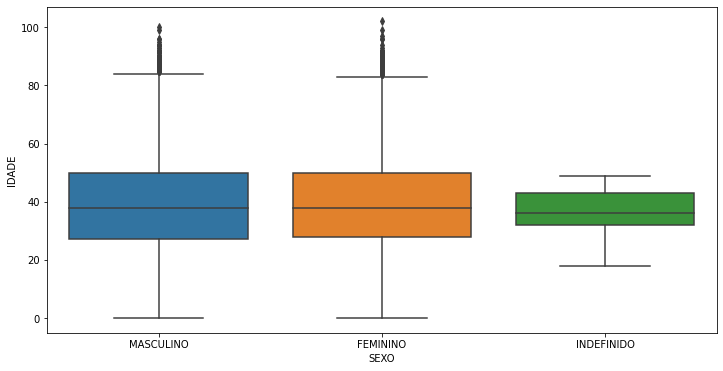

In [300]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(x='SEXO', y='IDADE',data=df_vdc)


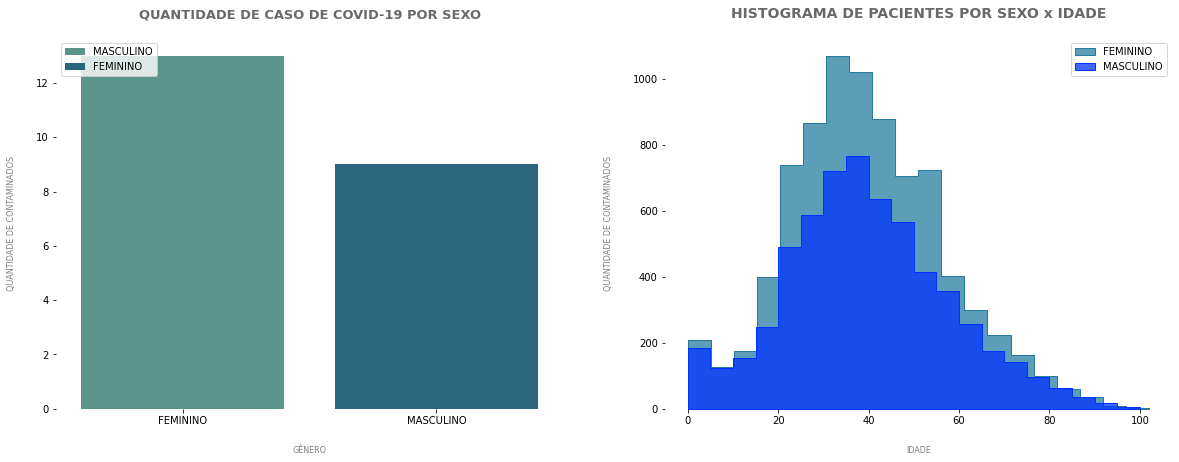

In [301]:
plt.figure(figsize=(20, 15))
s1 = plt.subplot(2, 2, 1)

s1 = sns.countplot(x = 'SEXO', data = df_marco, palette = 'crest', hue = 'SEXO', dodge= False
                   )
s2 = plt.title('QUANTIDADE DE CASO DE COVID-19 POR SEXO',
               pad = 20,
        fontsize = 13, color='dimgrey', fontweight = 'bold')

s1 = sns.despine(bottom = True, left =True)
s1 = plt.xlabel('GÊNERO', color = 'grey',labelpad = 20, fontsize = 8)
s1 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad= 20, fontsize = 8)
s1 = plt.legend(loc=2, labels=['MASCULINO', 'FEMININO'])

#########

s2 = plt.subplot(2, 2, 2)

sns.histplot(df_vdc[df_vdc['SEXO'] == 'FEMININO'] ['IDADE'], bins = 20, label ='FEMININO', element = 'step',
             color ='#257ca0')
sns.histplot(df_vdc[df_vdc['SEXO'] == 'MASCULINO'] ['IDADE'], bins = 20, label ='MASCULINO', element = 'step',
             color ='#0033FF')

s2 = plt.title('HISTOGRAMA DE PACIENTES POR SEXO x IDADE',
              pad = 20,
        fontsize = 14, color = 'dimgrey', fontweight = 'bold')

s2 = sns.despine(bottom = True, left = True)
s2 = plt.xlabel('IDADE', color = 'grey', labelpad = 20, fontsize =8)
s2 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad = 20, fontsize = 8)
s2 = plt.legend()

## **OBTENDO INFORMAÇÕES SOBRE CASOS DE COVID-19 DOS MESES ESTIPULADOS**

In [302]:
df_obitos.head(30)

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC
18,19/12/2020,04/01/2021,BA,VITORIA_DA_CONQUISTA,M,68,FILANTROPICO,S,"HIPERTENS�O (HAS),DOEN�A CARDIOVASCULAR (DCV)",0,0,VITORIA_DA_CONQUISTA
40,01/01/2021,03/01/2021,BA,VITORIA_DA_CONQUISTA,F,92,FILANTROPICO,S,DOEN�A CARDIOVASCULAR (DCV),0,0,VITORIA_DA_CONQUISTA
152,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,M,44,PUBLICO,S,HIPERTENS�O (HAS),0,0,VITORIA_DA_CONQUISTA
155,28/12/2020,30/12/2020,BA,VITORIA_DA_CONQUISTA,F,80,FILANTROPICO,SI,NaN,0,0,VITORIA_DA_CONQUISTA
241,26/12/2020,27/12/2020,BA,VITORIA_DA_CONQUISTA,M,62,PRIVADO,SI,NaN,0,0,VITORIA_DA_CONQUISTA
280,24/12/2020,26/12/2020,BA,VITORIA_DA_CONQUISTA,M,86,PUBLICO,S,"HIPERTENS�O (HAS),DOEN�A RENAL CR�NICA (DRC)",0,0,VITORIA_DA_CONQUISTA
281,24/12/2020,26/12/2020,BA,VITORIA_DA_CONQUISTA,M,59,PUBLICO,N,NaN,0,0,VITORIA_DA_CONQUISTA
282,23/12/2020,26/12/2020,BA,VITORIA_DA_CONQUISTA,F,86,FILANTROPICO,S,"HIPERTENS�O (HAS),DIABETES MELLITUS (DM)",0,0,VITORIA_DA_CONQUISTA
293,23/12/2020,25/12/2020,BA,VITORIA_DA_CONQUISTA,M,88,PUBLICO,S,DOEN�A RESPIRATORIA CRONICA,0,0,VITORIA_DA_CONQUISTA
315,07/12/2020,25/12/2020,BA,VITORIA_DA_CONQUISTA,M,92,PUBLICO,S,NEOPLASIA,0,0,VITORIA_DA_CONQUISTA


In [303]:
df_obitos['LIST_COMORB'].value_counts()

HIPERTENS�O (HAS),DIABETES MELLITUS (DM)                                                                           32
HIPERTENS�O (HAS)                                                                                                  25
DIABETES MELLITUS (DM)                                                                                             15
DOEN�A CARDIOVASCULAR (DCV)                                                                                        14
HIPERTENS�O (HAS),DOEN�A CARDIOVASCULAR (DCV)                                                                       8
DOEN�A RESPIRATORIA CRONICA                                                                                         6
DOEN�A CARDIOVASCULAR (DCV),DIABETES MELLITUS (DM)                                                                  5
DOEN�A DO SISTEMA NERVOSO                                                                                           5
OBESIDADE,HIPERTENS�O (HAS)                             

In [304]:
#Verificando a quantidade de dados faltantes
df_ausentes = df_obitos.isnull().sum()
print(df_ausentes)

DT_OBITO           0
DT_NOTIF_OBITO     0
UF_ESTD            0
MUNICIPIO          0
GENERO             0
IDADE              0
TP_ORGAO           8
COMORBIDADE        0
LIST_COMORB       57
IDADE_MESES        0
IDADE_DIAS         0
MUN_OCORRC         0
dtype: int64


###**VARIÁVEIS REFERENTES AOS MESES**

# **FEVEREIRO**

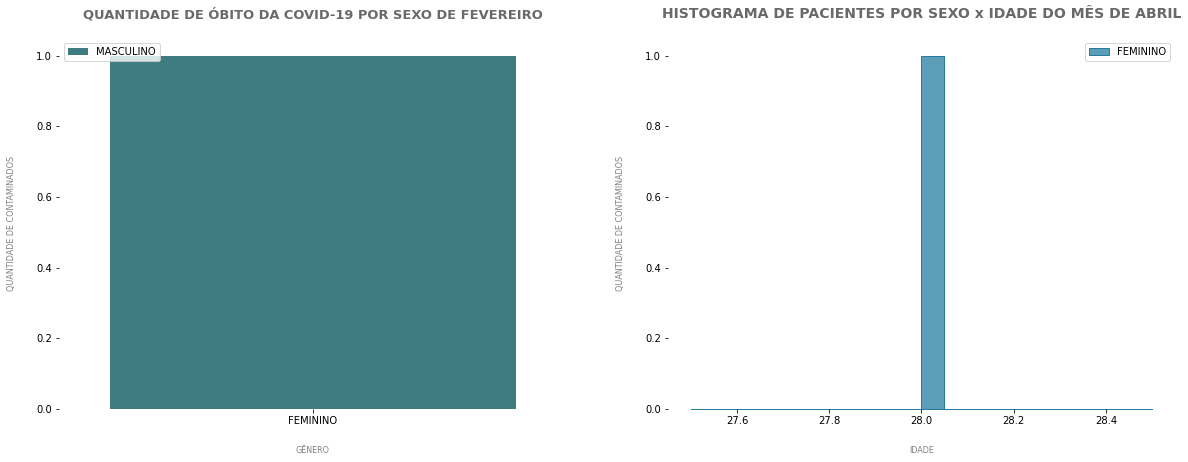

In [305]:
plt.figure(figsize=(20, 15))
s1 = plt.subplot(2, 2, 1)

s1 = sns.countplot(x = 'SEXO', data = df_fevereiro, palette = 'crest', hue = 'SEXO', dodge= False
                   )
s2 = plt.title('QUANTIDADE DE ÓBITO DA COVID-19 POR SEXO DE FEVEREIRO',
               pad = 20,
        fontsize = 13, color='dimgrey', fontweight = 'bold')

s1 = sns.despine(bottom = True, left =True)
s1 = plt.xlabel('GÊNERO', color = 'grey',labelpad = 20, fontsize = 8)
s1 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad= 20, fontsize = 8)
s1 = plt.legend(loc=2, labels=['MASCULINO', 'FEMININO'])

#########

s2 = plt.subplot(2, 2, 2)

sns.histplot(df_fevereiro[df_fevereiro['SEXO'] == 'FEMININO'] ['IDADE'], bins = 20, label ='FEMININO', element = 'step',
             color ='#257ca0')
sns.histplot(df_fevereiro[df_fevereiro['SEXO'] == 'MASCULINO'] ['IDADE'], bins = 20, label ='MASCULINO', element = 'step',
             color ='#0033FF')

s2 = plt.title('HISTOGRAMA DE PACIENTES POR SEXO x IDADE DO MÊS DE ABRIL',
              pad = 20,
        fontsize = 14, color = 'dimgrey', fontweight = 'bold')

s2 = sns.despine(bottom = True, left = True)
s2 = plt.xlabel('IDADE', color = 'grey', labelpad = 20, fontsize =8)
s2 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad = 20, fontsize = 8)
s2 = plt.legend()

#####**MARÇO**

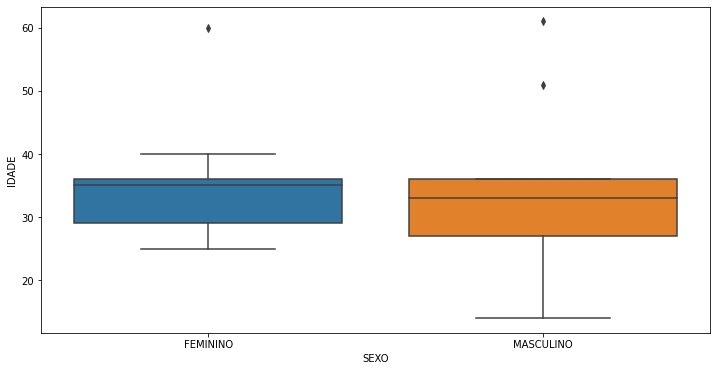

In [306]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(x='SEXO', y='IDADE',data=df_marco)


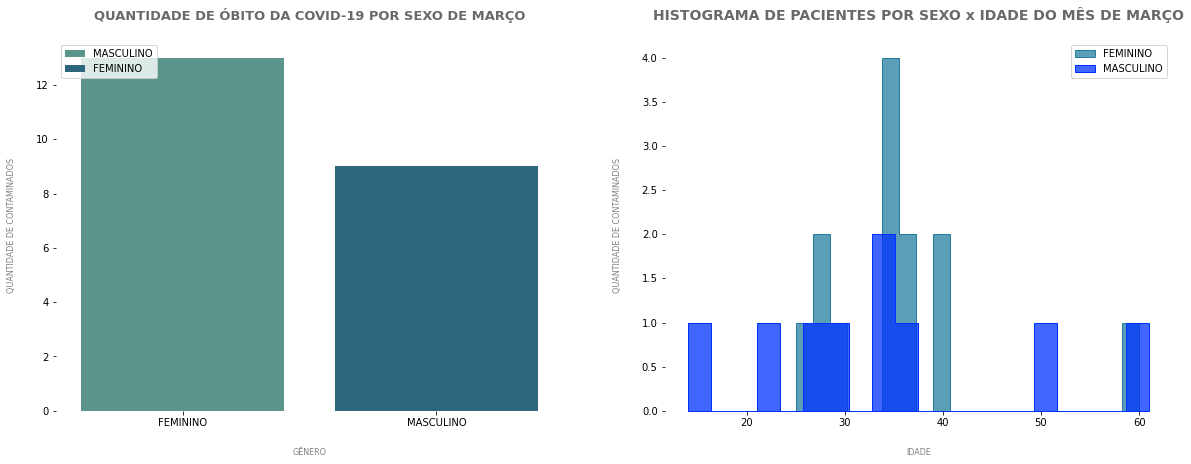

In [307]:
plt.figure(figsize=(20, 15))
s1 = plt.subplot(2, 2, 1)

s1 = sns.countplot(x = 'SEXO', data = df_marco, palette = 'crest', hue = 'SEXO', dodge= False
                   )
s2 = plt.title('QUANTIDADE DE ÓBITO DA COVID-19 POR SEXO DE MARÇO',
               pad = 20,
        fontsize = 13, color='dimgrey', fontweight = 'bold')

s1 = sns.despine(bottom = True, left =True)
s1 = plt.xlabel('GÊNERO', color = 'grey',labelpad = 20, fontsize = 8)
s1 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad= 20, fontsize = 8)
s1 = plt.legend(loc=2, labels=['MASCULINO', 'FEMININO'])

#########

s2 = plt.subplot(2, 2, 2)

sns.histplot(df_marco[df_marco['SEXO'] == 'FEMININO'] ['IDADE'], bins = 20, label ='FEMININO', element = 'step',
             color ='#257ca0')
sns.histplot(df_marco[df_marco['SEXO'] == 'MASCULINO'] ['IDADE'], bins = 20, label ='MASCULINO', element = 'step',
             color ='#0033FF')

s2 = plt.title('HISTOGRAMA DE PACIENTES POR SEXO x IDADE DO MÊS DE MARÇO',
              pad = 20,
        fontsize = 14, color = 'dimgrey', fontweight = 'bold')

s2 = sns.despine(bottom = True, left = True)
s2 = plt.xlabel('IDADE', color = 'grey', labelpad = 20, fontsize =8)
s2 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad = 20, fontsize = 8)
s2 = plt.legend()

#####**ABRIL**

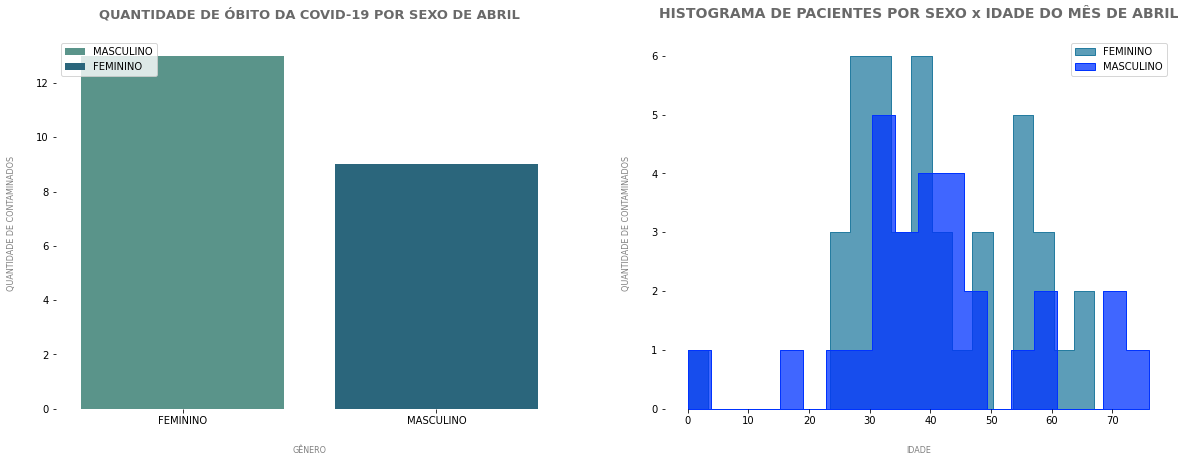

In [308]:
plt.figure(figsize=(20, 15))
s1 = plt.subplot(2, 2, 1)

s1 = sns.countplot(x = 'SEXO', data = df_marco, palette = 'crest', hue = 'SEXO', dodge= False
                   )
s2 = plt.title('QUANTIDADE DE ÓBITO DA COVID-19 POR SEXO DE ABRIL',
               pad = 20,
        fontsize = 13, color='dimgrey', fontweight = 'bold')

s1 = sns.despine(bottom = True, left =True)
s1 = plt.xlabel('GÊNERO', color = 'grey',labelpad = 20, fontsize = 8)
s1 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad= 20, fontsize = 8)
s1 = plt.legend(loc=2, labels=['MASCULINO', 'FEMININO'])

#########

s2 = plt.subplot(2, 2, 2)

sns.histplot(df_abril[df_abril['SEXO'] == 'FEMININO'] ['IDADE'], bins = 20, label ='FEMININO', element = 'step',
             color ='#257ca0')
sns.histplot(df_abril[df_abril['SEXO'] == 'MASCULINO'] ['IDADE'], bins = 20, label ='MASCULINO', element = 'step',
             color ='#0033FF')

s2 = plt.title('HISTOGRAMA DE PACIENTES POR SEXO x IDADE DO MÊS DE ABRIL',
              pad = 20,
        fontsize = 14, color = 'dimgrey', fontweight = 'bold')

s2 = sns.despine(bottom = True, left = True)
s2 = plt.xlabel('IDADE', color = 'grey', labelpad = 20, fontsize =8)
s2 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad = 20, fontsize = 8)
s2 = plt.legend()

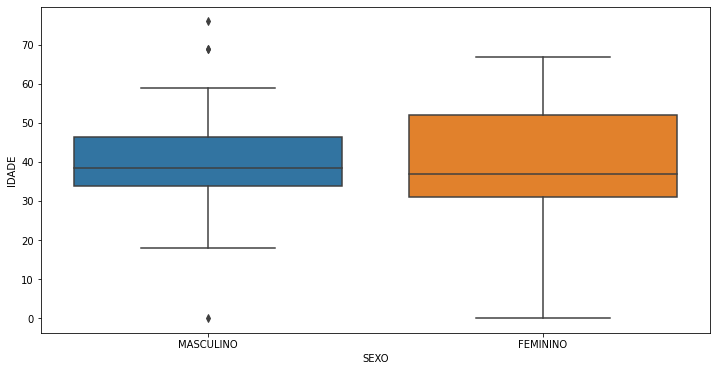

In [309]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(x='SEXO', y='IDADE',data=df_abril)


#####**MAIO**


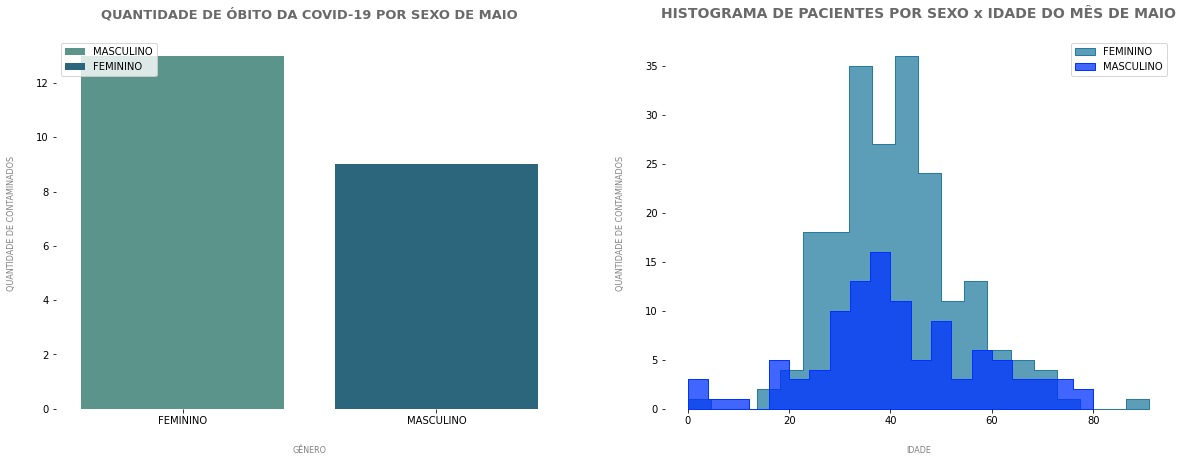

In [310]:
plt.figure(figsize=(20, 15))
s1 = plt.subplot(2, 2, 1)

s1 = sns.countplot(x = 'SEXO', data = df_marco, palette = 'crest', hue = 'SEXO', dodge= False
                   )
s2 = plt.title('QUANTIDADE DE ÓBITO DA COVID-19 POR SEXO DE MAIO',
               pad = 20,
        fontsize = 13, color='dimgrey', fontweight = 'bold')

s1 = sns.despine(bottom = True, left =True)
s1 = plt.xlabel('GÊNERO', color = 'grey',labelpad = 20, fontsize = 8)
s1 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad= 20, fontsize = 8)
s1 = plt.legend(loc=2, labels=['MASCULINO', 'FEMININO'])

#########

s2 = plt.subplot(2, 2, 2)

sns.histplot(df_maio[df_maio['SEXO'] == 'FEMININO'] ['IDADE'], bins = 20, label ='FEMININO', element = 'step',
             color ='#257ca0')
sns.histplot(df_maio[df_maio['SEXO'] == 'MASCULINO'] ['IDADE'], bins = 20, label ='MASCULINO', element = 'step',
             color ='#0033FF')

s2 = plt.title('HISTOGRAMA DE PACIENTES POR SEXO x IDADE DO MÊS DE MAIO',
              pad = 20,
        fontsize = 14, color = 'dimgrey', fontweight = 'bold')

s2 = sns.despine(bottom = True, left = True)
s2 = plt.xlabel('IDADE', color = 'grey', labelpad = 20, fontsize =8)
s2 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad = 20, fontsize = 8)
s2 = plt.legend()

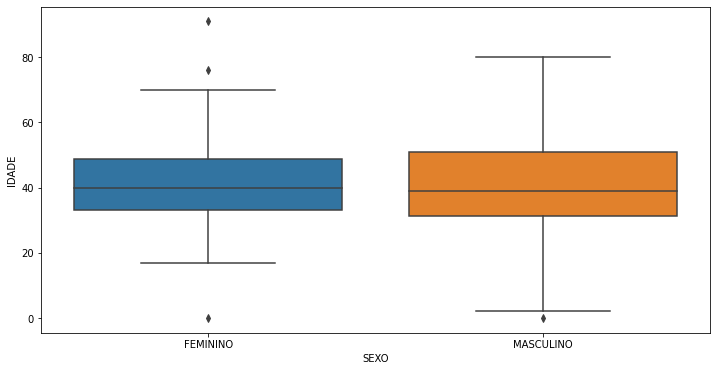

In [311]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(x='SEXO', y='IDADE',data=df_maio)


#####**JUNHO**

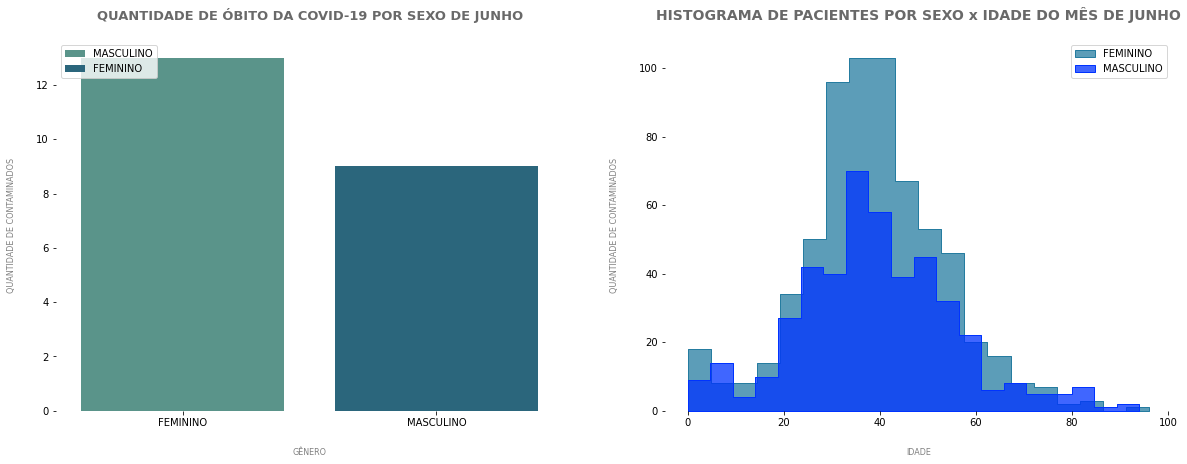

In [312]:
plt.figure(figsize=(20, 15))
s1 = plt.subplot(2, 2, 1)

s1 = sns.countplot(x = 'SEXO', data = df_marco, palette = 'crest', hue = 'SEXO', dodge= False
                   )
s2 = plt.title('QUANTIDADE DE ÓBITO DA COVID-19 POR SEXO DE JUNHO',
               pad = 20,
        fontsize = 13, color='dimgrey', fontweight = 'bold')

s1 = sns.despine(bottom = True, left =True)
s1 = plt.xlabel('GÊNERO', color = 'grey',labelpad = 20, fontsize = 8)
s1 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad= 20, fontsize = 8)
s1 = plt.legend(loc=2, labels=['MASCULINO', 'FEMININO'])

#########

s2 = plt.subplot(2, 2, 2)

sns.histplot(df_junho[df_junho['SEXO'] == 'FEMININO'] ['IDADE'], bins = 20, label ='FEMININO', element = 'step',
             color ='#257ca0')
sns.histplot(df_junho[df_junho['SEXO'] == 'MASCULINO'] ['IDADE'], bins = 20, label ='MASCULINO', element = 'step',
             color ='#0033FF')

s2 = plt.title('HISTOGRAMA DE PACIENTES POR SEXO x IDADE DO MÊS DE JUNHO',
              pad = 20,
        fontsize = 14, color = 'dimgrey', fontweight = 'bold')

s2 = sns.despine(bottom = True, left = True)
s2 = plt.xlabel('IDADE', color = 'grey', labelpad = 20, fontsize =8)
s2 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad = 20, fontsize = 8)
s2 = plt.legend()

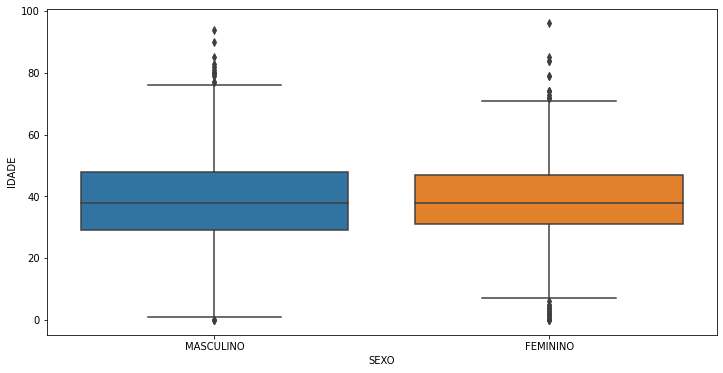

In [313]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(x='SEXO', y='IDADE',data=df_junho)


#####**JULHO**

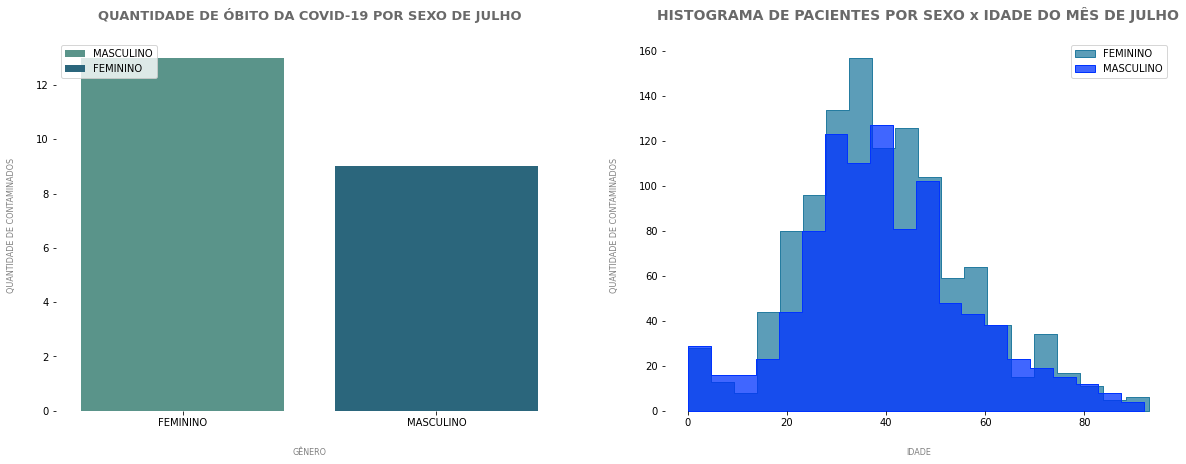

In [314]:
plt.figure(figsize=(20, 15))
s1 = plt.subplot(2, 2, 1)

s1 = sns.countplot(x = 'SEXO', data = df_marco, palette = 'crest', hue = 'SEXO', dodge= False
                   )
s2 = plt.title('QUANTIDADE DE ÓBITO DA COVID-19 POR SEXO DE JULHO',
               pad = 20,
        fontsize = 13, color='dimgrey', fontweight = 'bold')

s1 = sns.despine(bottom = True, left =True)
s1 = plt.xlabel('GÊNERO', color = 'grey',labelpad = 20, fontsize = 8)
s1 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad= 20, fontsize = 8)
s1 = plt.legend(loc=2, labels=['MASCULINO', 'FEMININO'])

#########

s2 = plt.subplot(2, 2, 2)

sns.histplot(df_julho[df_julho['SEXO'] == 'FEMININO'] ['IDADE'], bins = 20, label ='FEMININO', element = 'step',
             color ='#257ca0')
sns.histplot(df_julho[df_julho['SEXO'] == 'MASCULINO'] ['IDADE'], bins = 20, label ='MASCULINO', element = 'step',
             color ='#0033FF')

s2 = plt.title('HISTOGRAMA DE PACIENTES POR SEXO x IDADE DO MÊS DE JULHO',
              pad = 20,
        fontsize = 14, color = 'dimgrey', fontweight = 'bold')

s2 = sns.despine(bottom = True, left = True)
s2 = plt.xlabel('IDADE', color = 'grey', labelpad = 20, fontsize =8)
s2 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad = 20, fontsize = 8)
s2 = plt.legend()

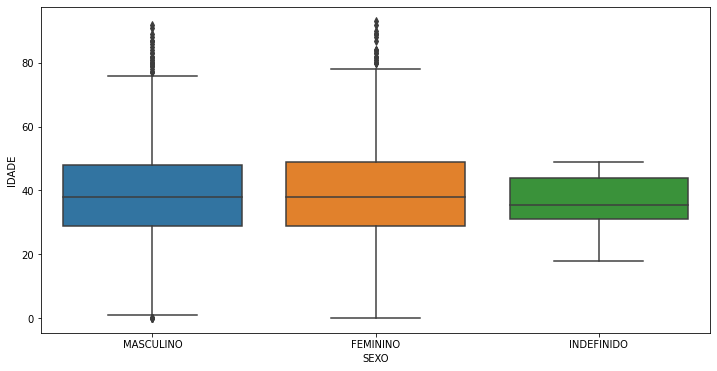

In [315]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(x='SEXO', y='IDADE',data=df_julho)


#####**AGOSTO**

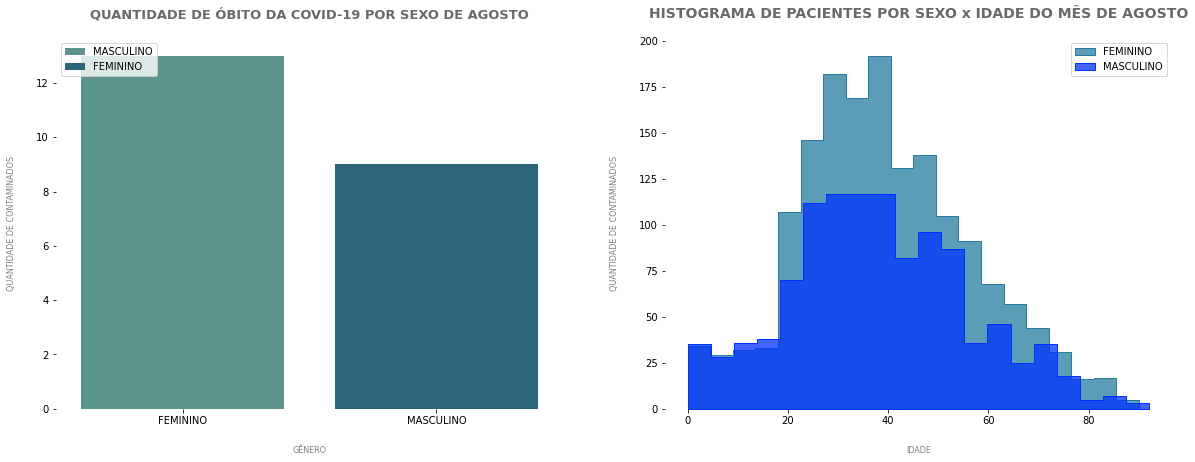

In [316]:
plt.figure(figsize=(20, 15))
s1 = plt.subplot(2, 2, 1)

s1 = sns.countplot(x = 'SEXO', data = df_marco, palette = 'crest', hue = 'SEXO', dodge= False
                   )
s2 = plt.title('QUANTIDADE DE ÓBITO DA COVID-19 POR SEXO DE AGOSTO',
               pad = 20,
        fontsize = 13, color='dimgrey', fontweight = 'bold')

s1 = sns.despine(bottom = True, left =True)
s1 = plt.xlabel('GÊNERO', color = 'grey',labelpad = 20, fontsize = 8)
s1 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad= 20, fontsize = 8)
s1 = plt.legend(loc=2, labels=['MASCULINO', 'FEMININO'])

#########

s2 = plt.subplot(2, 2, 2)

sns.histplot(df_agosto[df_agosto['SEXO'] == 'FEMININO'] ['IDADE'], bins = 20, label ='FEMININO', element = 'step',
             color ='#257ca0')
sns.histplot(df_agosto[df_agosto['SEXO'] == 'MASCULINO'] ['IDADE'], bins = 20, label ='MASCULINO', element = 'step',
             color ='#0033FF')

s2 = plt.title('HISTOGRAMA DE PACIENTES POR SEXO x IDADE DO MÊS DE AGOSTO',
              pad = 20,
        fontsize = 14, color = 'dimgrey', fontweight = 'bold')

s2 = sns.despine(bottom = True, left = True)
s2 = plt.xlabel('IDADE', color = 'grey', labelpad = 20, fontsize =8)
s2 = plt.ylabel('QUANTIDADE DE CONTAMINADOS', color = 'grey', labelpad = 20, fontsize = 8)
s2 = plt.legend()

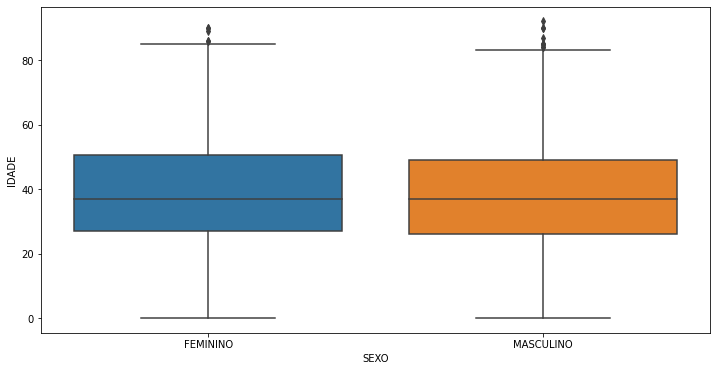

In [317]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.boxplot(x='SEXO', y='IDADE',data=df_agosto)


In [318]:
#Verificando a quantidade de dados nulos e ordenando
df_vdc.isnull().sum().sort_values(ascending=False)[:10]

CBO                12671
DT_COLT_TEST          21
ESTADO_TEST            2
IMUNOSSUPRESSAO        0
DT_NOTIFIC             0
DOR_GARGANTA           0
DISPNEIA               0
FEBRE                  0
TOSSE                  0
OUTROS                 0
dtype: int64

##**Obtendo média, moda e mediana das idades para cada mês**

In [319]:
#Média de Março
df_marco['IDADE'].mean()

34.95454545454545

In [320]:
#Moda de Março
df_marco['IDADE'].mode()


0    35.0
dtype: float64

In [321]:
#Mediana de Março
df_marco['IDADE'].median()

35.0

In [322]:
#Média de Abril
df_abril['IDADE'].mean()

40.74647887323944

In [323]:
#Moda de Abril
df_abril['IDADE'].mode()

0    37.0
dtype: float64

In [324]:
#Mediana de Abril
df_abril['IDADE'].median()

38.0

In [325]:
#Média de Junho
df_junho['IDADE'].mean()

38.85131459655485

In [326]:
#Moda de Junho
df_junho['IDADE'].mode()

0    33.0
dtype: float64

In [327]:
#Mediana de Junho
df_junho['IDADE'].median()

38.0

In [328]:
#Desvio padrão de Junho
df_junho['IDADE'].std()

15.306891310501344

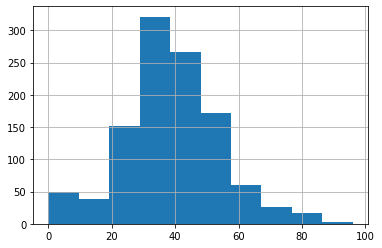

In [329]:
df_junho['IDADE'].hist()

In [330]:
#Verificando a quantidade de dados nulos com o sum, caso seja True
df_vdc.isnull()

,DT_COLT_TEST,DT_NOTIFIC,DOR_GARGANTA,DISPNEIA,FEBRE,TOSSE,OUTROS,PROFI_DE_SAUDE,DT_INICIO_SINTOMAS,DOENCAS_RESP_CRON_DESCOMP,DOENCAS_CARD_CRON,DIABETES,DOENCAS_RENAIS_CRON_ESTAG_AVAN_3_4_5,IMUNOSSUPRESSAO,GESTA_ALTO_RISC,DOENCAS_CROMOS_OU_FRAGI_IMUNO,CLAS_FINAL,INVESTI_CONC,ESTADO_TEST,CBO,IDADE,TP_IDADE,TP_TEST,RESULT_TEST,SEXO,ESTD_RESI,MUN_RESI,BANCO,RACA_COR,EPIDEMIA,RESULT
123,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
129,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
168,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
231,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
234,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496747,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
496763,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
496776,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
496777,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


##**ANÁLISE DOS ÓBITOS DECORRENTES À COVID-19**

#####**FEVEREIRO**

In [331]:
# Selecionando datas referentes ao mês de Fevereiro entre as data 01/02/2020 e 29/02/2020
df_ob_fev = (df_obitos['DT_OBITO'] >= '2020-02-01') & (df_obitos['DT_OBITO'] <= '2020-02-29')

df_ob_fevereiro = df_obitos[df_ob_fev] 
df_ob_fevereiro.sort_values(by='DT_OBITO', ascending=False)

#Conclui-se que não houve caso de óbito na cidade no mês de Fevereiro

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC


#####**MARÇO**

In [332]:
# Selecionando datas referentes ao mês de Março 
df_ob_mar = (df_obitos['DT_OBITO'] >= '2020-03-01') & (df_obitos['DT_OBITO'] <= '2020-03-31')

df_ob_marco = df_obitos[df_ob_mar] 
df_ob_marco.sort_values(by='DT_OBITO', ascending=False)

#Conclui-se que não houve caso de óbito na cidade no mês de Março

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC


#####**ABRIL**

In [333]:
# Selecionando datas referentes ao mês de Abril
df_ob_abr = (df_obitos['DT_OBITO'] >= '2020-04-01') & (df_obitos['DT_OBITO'] <= '2020-04-30')

df_ob_abril = df_obitos[df_ob_abr] 
df_ob_abril.sort_values(by='DT_OBITO', ascending=False)

#No mês de Abril ocorreram três mortes pela doença, a cidade o primeiro óbito no dia 13/04/2020

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC


#####**MAIO**

In [334]:
# Selecionando datas referentes ao mês de Maio
df_ob_mai = (df_obitos['DT_OBITO'] >= '2020-05-01') & (df_obitos['DT_OBITO'] <= '2020-05-31')

df_ob_maio = df_obitos[df_ob_mai] 
df_ob_maio.sort_values(by='DT_OBITO', ascending=False)



,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC


#####**JUNHO**

In [335]:
# Selecionando datas referentes ao mês de Junho
df_ob_jun = (df_obitos['DT_OBITO'] >= '2020-06-01') & (df_obitos['DT_OBITO'] <= '2020-06-30')

df_ob_junho = df_obitos[df_ob_jun] 
df_ob_junho.sort_values(by='DT_OBITO', ascending=False).head(2)

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC


#####**JULHO**

In [336]:
# Selecionando datas referentes ao mês de Julho
df_ob_jul = (df_obitos['DT_OBITO'] >= '2020-07-01') & (df_obitos['DT_OBITO'] <= '2020-07-31')

df_ob_julho = df_obitos[df_ob_jul] 
df_ob_julho.sort_values(by='DT_OBITO', ascending=False).head(4)

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC


#####**AGOSTO**

In [337]:
# Selecionando datas referentes ao mês de Agosto
df_ob_ago = (df_obitos['DT_OBITO'] >= '2020-08-01') & (df_obitos['DT_OBITO'] <= '2020-08-31')

df_ob_agosto = df_obitos[df_ob_ago] 
df_ob_agosto.sort_values(by='DT_OBITO', ascending=False).head(4)

,DT_OBITO,DT_NOTIF_OBITO,UF_ESTD,MUNICIPIO,GENERO,IDADE,TP_ORGAO,COMORBIDADE,LIST_COMORB,IDADE_MESES,IDADE_DIAS,MUN_OCORRC


In [338]:
#Verificando a quantidade de dados faltantes
df_faltantes = df_idade.isnull().sum()
print(df_faltantes)

0


In [339]:
#Verificando a idade com a mediana
df_mediana = df_vdc['IDADE'].median()
print(df_mediana)

38.0


In [340]:
#dados.loc[(c.replace(' ', '_') for c in dados.columns)] = 'VITORIA_DA_CONQUISTA'

In [341]:
#dados.columns = [c.replace(' ', '_') for c in dados.columns]

In [342]:
#import matplotlib.pyplot as plt
#plt.figure(figsize=(12,6))
#sns.boxplot(x='RACA_COR', y='IDADE',data=df_vdc)

